#### Placebo / randomization-inference null for the neighbor effect — frequency-pruned sequences
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-06-25

**Design (matches the paper's placebo, then filtered).** We reuse the *same position randomizations* as the main
analysis: within each occupation we shuffle the full task sequence's positions with `random_state = 42 + i`
(identical mechanic to the paper). A single shuffle randomizes **all four** neighbor relations (t-2, t-1, t+1,
t+2) at once. For each frequency cut we then **apply the frequency filter to the already-randomized sequence**,
recompute neighbor flags on the surviving tasks (which close ranks), and re-estimate. One shuffle per draw
serves every cut.

We re-run **all six specifications** (no FE, Major FE, Minor FE, DWA FE, + the two "tasks-in-DWA-within-
occupation" controls). For each cut we plot the reshuffled-null histogram of the AME against the observed AME
(red dashed) — the equivalent of the paper's placebo histograms — and report a two-sided randomization p-value.

**Full run: `N_RESHUFFLES = 1000`** (the timing trial measured ~4.0 s/draw → ~1.1 h). The null draws are saved
incrementally so a long run is recoverable.

In [1]:
import os, glob, time
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy.special import expit
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

In [2]:
# ====================== PARAMETERS ======================
N_RESHUFFLES = 1000          # full run (timing trial confirmed ~4.0s/draw -> ~1.1h)
SHUFFLE_SEED_BASE = 42       # same base seed as the main-analysis placebo

dependent_var = 'is_ai'
TARGET_REGS = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
TERM_TITLE = {'prev2_is_ai':'(t-2)', 'prev_is_ai':'(t-1)', 'next_is_ai':'(t+1)', 'next2_is_ai':'(t+2)'}

ALL_FT_COLS = ['FT_Yearly or less', 'FT_More than yearly', 'FT_More than monthly', 'FT_More than weekly',
               'FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']
FT_DAILY        = ['FT_Daily', 'FT_Several times daily', 'FT_Hourly or more']        # FT 5-7
FT_SEVERALDAILY = ['FT_Several times daily', 'FT_Hourly or more']                     # FT 6-7
FT_HOURLY       = ['FT_Hourly or more']                                               # FT 7
FAMILIES = [('Daily+', 'daily', FT_DAILY), ('SeveralDaily+', 'sevdaily', FT_SEVERALDAILY), ('Hourly+', 'hourly', FT_HOURLY)]
SWEEP_THRESHOLDS = [20, 35, 50, 65]

# Placebo cuts: All-tasks baseline + the three logics x four thresholds
PLACEBO_CUTS = [('All tasks', 'all', None, None)]
for lab, tag, cols in FAMILIES:
    for t in SWEEP_THRESHOLDS:
        PLACEBO_CUTS.append((f"{lab} >={t}%", f"{tag}{t}", cols, t))

# All six specifications (label, formula-suffix builder handled in fit_all_specs)
SPEC_ORDER = ['no_fe_no_dwa', 'major_fe_no_dwa', 'minor_fe_no_dwa', 'no_fe_with_dwa',
              'no_fe_no_dwa_withTaskDWACount', 'no_fe_with_dwa_withTaskDWACount']
SPEC_LABEL = {'no_fe_no_dwa':'No FE', 'major_fe_no_dwa':'Major FE', 'minor_fe_no_dwa':'Minor FE',
              'no_fe_with_dwa':'DWA FE', 'no_fe_no_dwa_withTaskDWACount':'No FE + TaskDWAcount',
              'no_fe_with_dwa_withTaskDWACount':'DWA FE + TaskDWAcount'}
MIN_TASKS_PER_OCC = 5    # keep occupations whose frequency-pruned workflow retains >=5 steps (shared sample def)


In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
output_data_path = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_weeklyTasks"
output_plot_path = f"{main_folder_path}/writeup/plots/execTypeVaryingDWA_weeklyTasks/placebo"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## Load DWA helpers and build the full task POOL (DWA-filtered, all frequencies, no edge-drop)

In [4]:
dwa_csv_files = glob.glob(os.path.join(f"{input_data_path}/computed_objects/similar_dwa_tasks/similarTasks", "*.csv"))
df_all = pd.concat([d for d in (pd.read_csv(f) for f in dwa_csv_files) if len(d) > 1], ignore_index=True)
dwa_task_mapping = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
dwa_task_counts = dwa_task_mapping.groupby('Task ID')['DWA ID'].nunique().reset_index(name='n')
unique_task_dwa_mapping = dwa_task_counts[dwa_task_counts['n'] == 1]['Task ID'].tolist()

def build_pool():
    '''Full task workflow (all frequencies, NO DWA filter, NO neighbor edge-drop). The frequency filter,
    neighbor recompute, AND DWA filters all happen per-cut in cut_pipeline, AFTER the position shuffle, so
    neighbor flags are computed on the true workflow sequence BEFORE any DWA thinning (matching build_dataset
    in the main neighbor analysis).'''
    d = pd.read_csv(merged_file)
    d = d[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
           'Major_Group_Code', 'Minor_Group_Code', 'gpt4_exposure', 'human_labels', 'label'] + ALL_FT_COLS].copy()
    d['is_ai'] = d['label'].isin(['Augmentation', 'Automation']).astype(int)
    d['is_exposed'] = d['human_labels'].isin(['E1']).astype(int)
    d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
    sc = d.select_dtypes(include=['string']).columns; d[sc] = d[sc].astype(object)
    return d

POOL = build_pool()
print(f"POOL: {len(POOL):,} task-rows, {POOL['O*NET-SOC Code'].nunique():,} occupations (full workflow; DWA filters applied per-cut)")

# Shared sample definition (see valid_occ_set)
_VOS_RAW = pd.read_csv(merged_file)[['O*NET-SOC Code', 'Task ID'] + ALL_FT_COLS].copy()
_VOS_CACHE = {}
def valid_occ_set(family_cols, threshold):
    """Shared sample def: occupations whose frequency-pruned workflow retains >=MIN_TASKS_PER_OCC tasks (steps).
    Counted on the FULL workflow (not the DWA-eligible pool); frequency filter is per-task so this set is
    invariant to within-occupation position reshuffles."""
    key = (None if family_cols is None else tuple(family_cols), threshold)
    if key not in _VOS_CACHE:
        d = _VOS_RAW if family_cols is None else _VOS_RAW[_VOS_RAW[family_cols].sum(axis=1) >= threshold]
        cnt = d.groupby('O*NET-SOC Code')['Task ID'].nunique()
        _VOS_CACHE[key] = set(cnt[cnt >= MIN_TASKS_PER_OCC].index)
    return _VOS_CACHE[key]


POOL: 17,925 task-rows, 872 occupations (full workflow; DWA filters applied per-cut)


## Per-cut pipeline (filter → recompute neighbors on current order → edge-drop) and the shuffle

In [5]:
def cut_pipeline(pool, family_cols, threshold):
    '''Frequency filter -> neighbor flags on the FULL workflow sequence -> edge dropna -> DWA filters,
    matching build_dataset in the main neighbor analysis (neighbors are computed BEFORE DWA thinning, so a
    focal task's neighbor is its true adjacent workflow task). `pool` may already be position-shuffled.'''
    d = pool if family_cols is None else pool[pool[family_cols].sum(axis=1) >= threshold].reset_index(drop=True)
    n = d.groupby('O*NET-SOC Code')['Task ID'].nunique().reset_index().rename(columns={'Task ID': 'num_tasks'})
    d = d.merge(n, on='O*NET-SOC Code', how='left')
    d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
    g = d.groupby('O*NET-SOC Code')['is_ai']
    d['prev_is_ai'] = g.shift(1); d['prev2_is_ai'] = g.shift(2); d['next_is_ai'] = g.shift(-1); d['next2_is_ai'] = g.shift(-2)
    nbc = ['prev_is_ai', 'prev2_is_ai', 'next_is_ai', 'next2_is_ai']
    d = d.dropna(subset=nbc).reset_index(drop=True)
    for c in nbc: d[c] = d[c].astype(int)
    # ---- DWA filters (AFTER neighbor flags), identical to build_dataset / the main analysis ----
    d = d.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
    d = d[d['Task ID'].isin(unique_task_dwa_mapping)].reset_index(drop=True)        # single-DWA tasks
    d = d.drop_duplicates(subset=['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)
    d = d[~d['DWA ID'].isna()].reset_index(drop=True)
    occ = d.groupby('DWA ID')['O*NET-SOC Code'].nunique(); d = d[d['DWA ID'].isin(occ[occ > 1].index)].reset_index(drop=True)
    cnt = d.groupby(['DWA ID', 'O*NET-SOC Code'])['Task ID'].nunique().reset_index(name='num_tasks_in_dwa_within_occupation')
    d = d.merge(cnt, on=['DWA ID', 'O*NET-SOC Code'], how='left')
    d['DWA_ID'] = d['DWA ID']
    # keep occupations whose frequency-pruned workflow retains >=MIN_TASKS_PER_OCC steps (shared sample def)
    d = d[d['O*NET-SOC Code'].isin(valid_occ_set(family_cols, threshold))].reset_index(drop=True)
    return d

def shuffle_pool(pool, seed):
    '''Reproduce the main-analysis position randomization: within each occupation, permute Task Position
    with random_state=seed (same mechanic as the paper). One shuffle serves all cuts for this draw.'''
    d = pool.copy()
    d['Task Position'] = d.groupby('O*NET-SOC Code')['Task Position'].transform(
        lambda x: x.sample(frac=1, random_state=seed).values)
    return d

## AME estimator across all six specifications (point estimates)

In [6]:
def _ame(res, df, target):
    out = {}
    for v in target:
        d1 = df.copy(); d0 = df.copy(); d1[v] = 1; d0[v] = 0
        out[v] = float(np.mean(res.predict(d1) - res.predict(d0)))
    return out

def fit_all_specs(d, target=TARGET_REGS, dep=dependent_var):
    '''Point-estimate AMEs for all six specs. Plain logit fit (no clustered cov needed for point AMEs).'''
    base = f'{dep} ~ ' + ' + '.join(target)
    df_dwa = d.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    specs = [
        ('no_fe_no_dwa', base + ' + is_exposed + num_tasks', d),
        ('major_fe_no_dwa', base + ' + C(Major_Group_Code) + is_exposed + num_tasks',
            d.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1)),
        ('minor_fe_no_dwa', base + ' + C(Minor_Group_Code) + is_exposed + num_tasks',
            d.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1)),
        ('no_fe_with_dwa', base + ' + C(DWA_ID) + is_exposed + num_tasks', df_dwa),
        ('no_fe_no_dwa_withTaskDWACount', base + ' + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa),
    ]
    out = {}
    for name, formula, data in specs:
        try:
            if len(data) < 30 or data[dep].nunique() < 2:
                raise ValueError('too small')
            res = smf.logit(formula, data=data).fit(disp=False)
            out[name] = _ame(res, data, target)
        except Exception:
            out[name] = {t: np.nan for t in target}
    return out


def _ame_and_se(res, target):
    '''Discrete-change AME and its delta-method SE from a cluster-robust logit fit (for the observed markers).'''
    X = np.asarray(res.model.exog, float); names = list(res.model.exog_names)
    beta = np.asarray(res.params, float); V = np.asarray(res.cov_params(), float)
    out = {}
    for v in target:
        if v not in names:
            out[v] = (np.nan, np.nan); continue
        j = names.index(v)
        X1 = X.copy(); X1[:, j] = 1.0; X0 = X.copy(); X0[:, j] = 0.0
        p1 = expit(X1 @ beta); p0 = expit(X0 @ beta)
        g = ((p1*(1-p1))[:, None]*X1 - (p0*(1-p0))[:, None]*X0).mean(axis=0)
        out[v] = (float(np.mean(p1 - p0)), float(np.sqrt(max(g @ V @ g, 0.0))))
    return out


def observed_specs(d, target=TARGET_REGS, dep=dependent_var):
    '''Observed AME + clustered delta-method SE for all six specs (markers + 90% CI band for the plots).'''
    base = f'{dep} ~ ' + ' + '.join(target)
    df_dwa = d.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    specs = [
        ('no_fe_no_dwa', base + ' + is_exposed + num_tasks', d),
        ('major_fe_no_dwa', base + ' + C(Major_Group_Code) + is_exposed + num_tasks',
            d.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1)),
        ('minor_fe_no_dwa', base + ' + C(Minor_Group_Code) + is_exposed + num_tasks',
            d.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1)),
        ('no_fe_with_dwa', base + ' + C(DWA_ID) + is_exposed + num_tasks', df_dwa),
        ('no_fe_no_dwa_withTaskDWACount', base + ' + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + is_exposed + num_tasks + num_tasks_in_dwa_within_occupation', df_dwa),
    ]
    out = {}
    for name, formula, data in specs:
        try:
            if len(data) < 30 or data[dep].nunique() < 2:
                raise ValueError('too small')
            res = smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                    cov_kwds={'groups': data['DWA ID'], 'use_correction': True})
            out[name] = _ame_and_se(res, target)
        except Exception:
            out[name] = {t: (np.nan, np.nan) for t in target}
    return out

## Observed AMEs (no shuffle) — markers for the histograms + sanity check

In [7]:
observed = {}   # observed[tag][spec][term] = (ame, se)
for label, tag, cols, thr in PLACEBO_CUTS:
    observed[tag] = observed_specs(cut_pipeline(POOL, cols, thr))
obs_rows = [{'cut_tag': tag, 'cut': lbl, 'spec': sp, 'term': tm,
             'ame': observed[tag][sp][tm][0], 'se': observed[tag][sp][tm][1]}
            for (lbl, tag, cols, thr) in PLACEBO_CUTS for sp in SPEC_ORDER for tm in TARGET_REGS]
pd.DataFrame(obs_rows).to_csv(f"{output_data_path}/placebo_observed.csv", index=False)
# sanity vs the sweep (Daily+ >=50%, no FE): expect t-1 ~ 0.086, t+1 ~ 0.084
print("sanity — Daily+ >=50%, no FE observed AME:  (t-1) =",
      round(observed['daily50']['no_fe_no_dwa']['prev_is_ai'][0], 3),
      " (t+1) =", round(observed['daily50']['no_fe_no_dwa']['next_is_ai'][0], 3))

sanity — Daily+ >=50%, no FE observed AME:  (t-1) = 0.086  (t+1) = 0.084


## Reshuffle loop (N_RESHUFFLES draws). One shuffle per draw, reused across all cuts; saved incrementally.

In [8]:
null_rows = []
t0 = time.time()
PRINT_EVERY = max(1, N_RESHUFFLES // 40)
SAVE_EVERY = max(1, N_RESHUFFLES // 10)   # incremental save so a long run is recoverable
for i in range(N_RESHUFFLES):
    sp_pool = shuffle_pool(POOL, SHUFFLE_SEED_BASE + i)   # one randomization for this draw, shared across cuts
    for label, tag, cols, thr in PLACEBO_CUTS:
        res = fit_all_specs(cut_pipeline(sp_pool, cols, thr))
        for spec in SPEC_ORDER:
            for term in TARGET_REGS:
                null_rows.append({'cut_tag': tag, 'cut': label, 'spec': spec, 'term': term,
                                  'draw': i, 'ame': res[spec][term]})
    if (i + 1) % PRINT_EVERY == 0 or i == 0:
        el = time.time() - t0
        print(f"  draw {i+1}/{N_RESHUFFLES} | elapsed {el/60:5.1f}m | {el/(i+1):4.2f}s/draw "
              f"| proj total {el/(i+1)*N_RESHUFFLES/3600:4.2f}h", flush=True)
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(null_rows).to_csv(f"{output_data_path}/placebo_null_draws.csv", index=False)

null_df = pd.DataFrame(null_rows)
null_df.to_csv(f"{output_data_path}/placebo_null_draws.csv", index=False)
total = time.time() - t0
print(f"\nTIMING: {N_RESHUFFLES} draws x {len(PLACEBO_CUTS)} cuts x {len(SPEC_ORDER)} specs in {total/60:.1f} min "
      f"({total/N_RESHUFFLES:.2f}s/draw).")
print(f"Saved null draws ({len(null_df):,} rows) and observed AMEs to {output_data_path}")

  draw 1/1000 | elapsed   0.1m | 3.33s/draw | proj total 0.92h


  draw 25/1000 | elapsed   1.5m | 3.71s/draw | proj total 1.03h


  draw 50/1000 | elapsed   3.0m | 3.55s/draw | proj total 0.99h


  draw 75/1000 | elapsed   4.4m | 3.53s/draw | proj total 0.98h


  draw 100/1000 | elapsed   6.1m | 3.67s/draw | proj total 1.02h


...

  draw 925/1000 | elapsed  91.5m | 5.93s/draw | proj total 1.65h


  draw 950/1000 | elapsed  97.1m | 6.13s/draw | proj total 1.70h


  draw 975/1000 | elapsed  98.3m | 6.05s/draw | proj total 1.68h


  draw 1000/1000 | elapsed  99.6m | 5.98s/draw | proj total 1.66h



TIMING: 1000 draws x 13 cuts x 6 specs in 99.6 min (5.98s/draw).
Saved null draws (312,000 rows) and observed AMEs to ../data/computed_objects/execTypeVaryingDWA_anthropicIndex_weeklyTasks


## Placebo histograms — one figure per cut (rows = 6 specs, cols = 4 neighbor positions)

Red dashed = observed AME; black line = 0. Title of each panel shows the two-sided randomization p-value
(share of reshuffles with |AME| at least as large as observed).

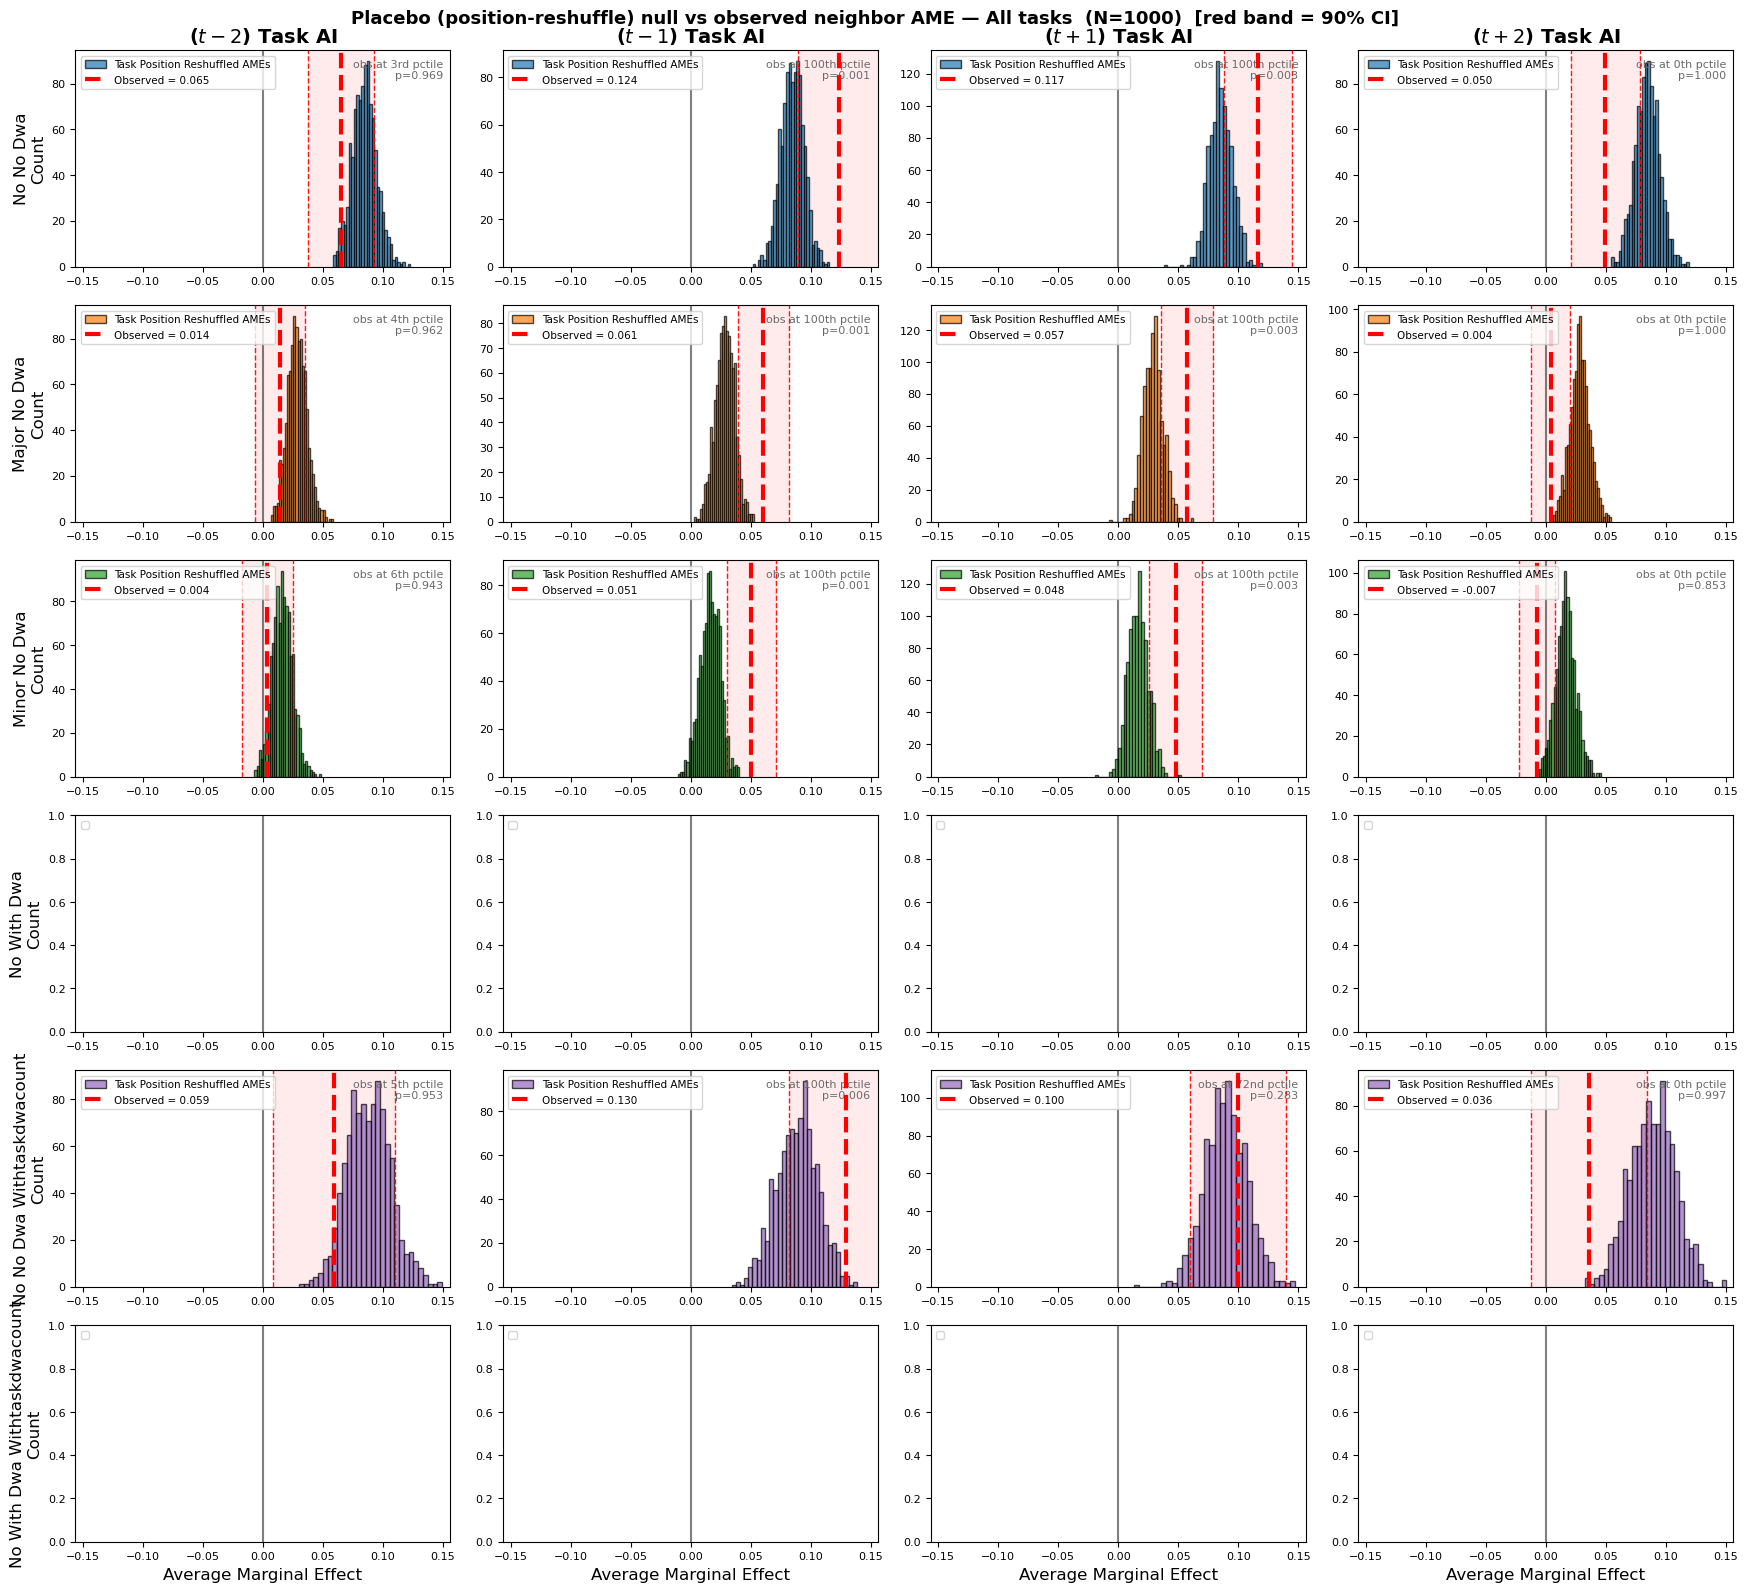

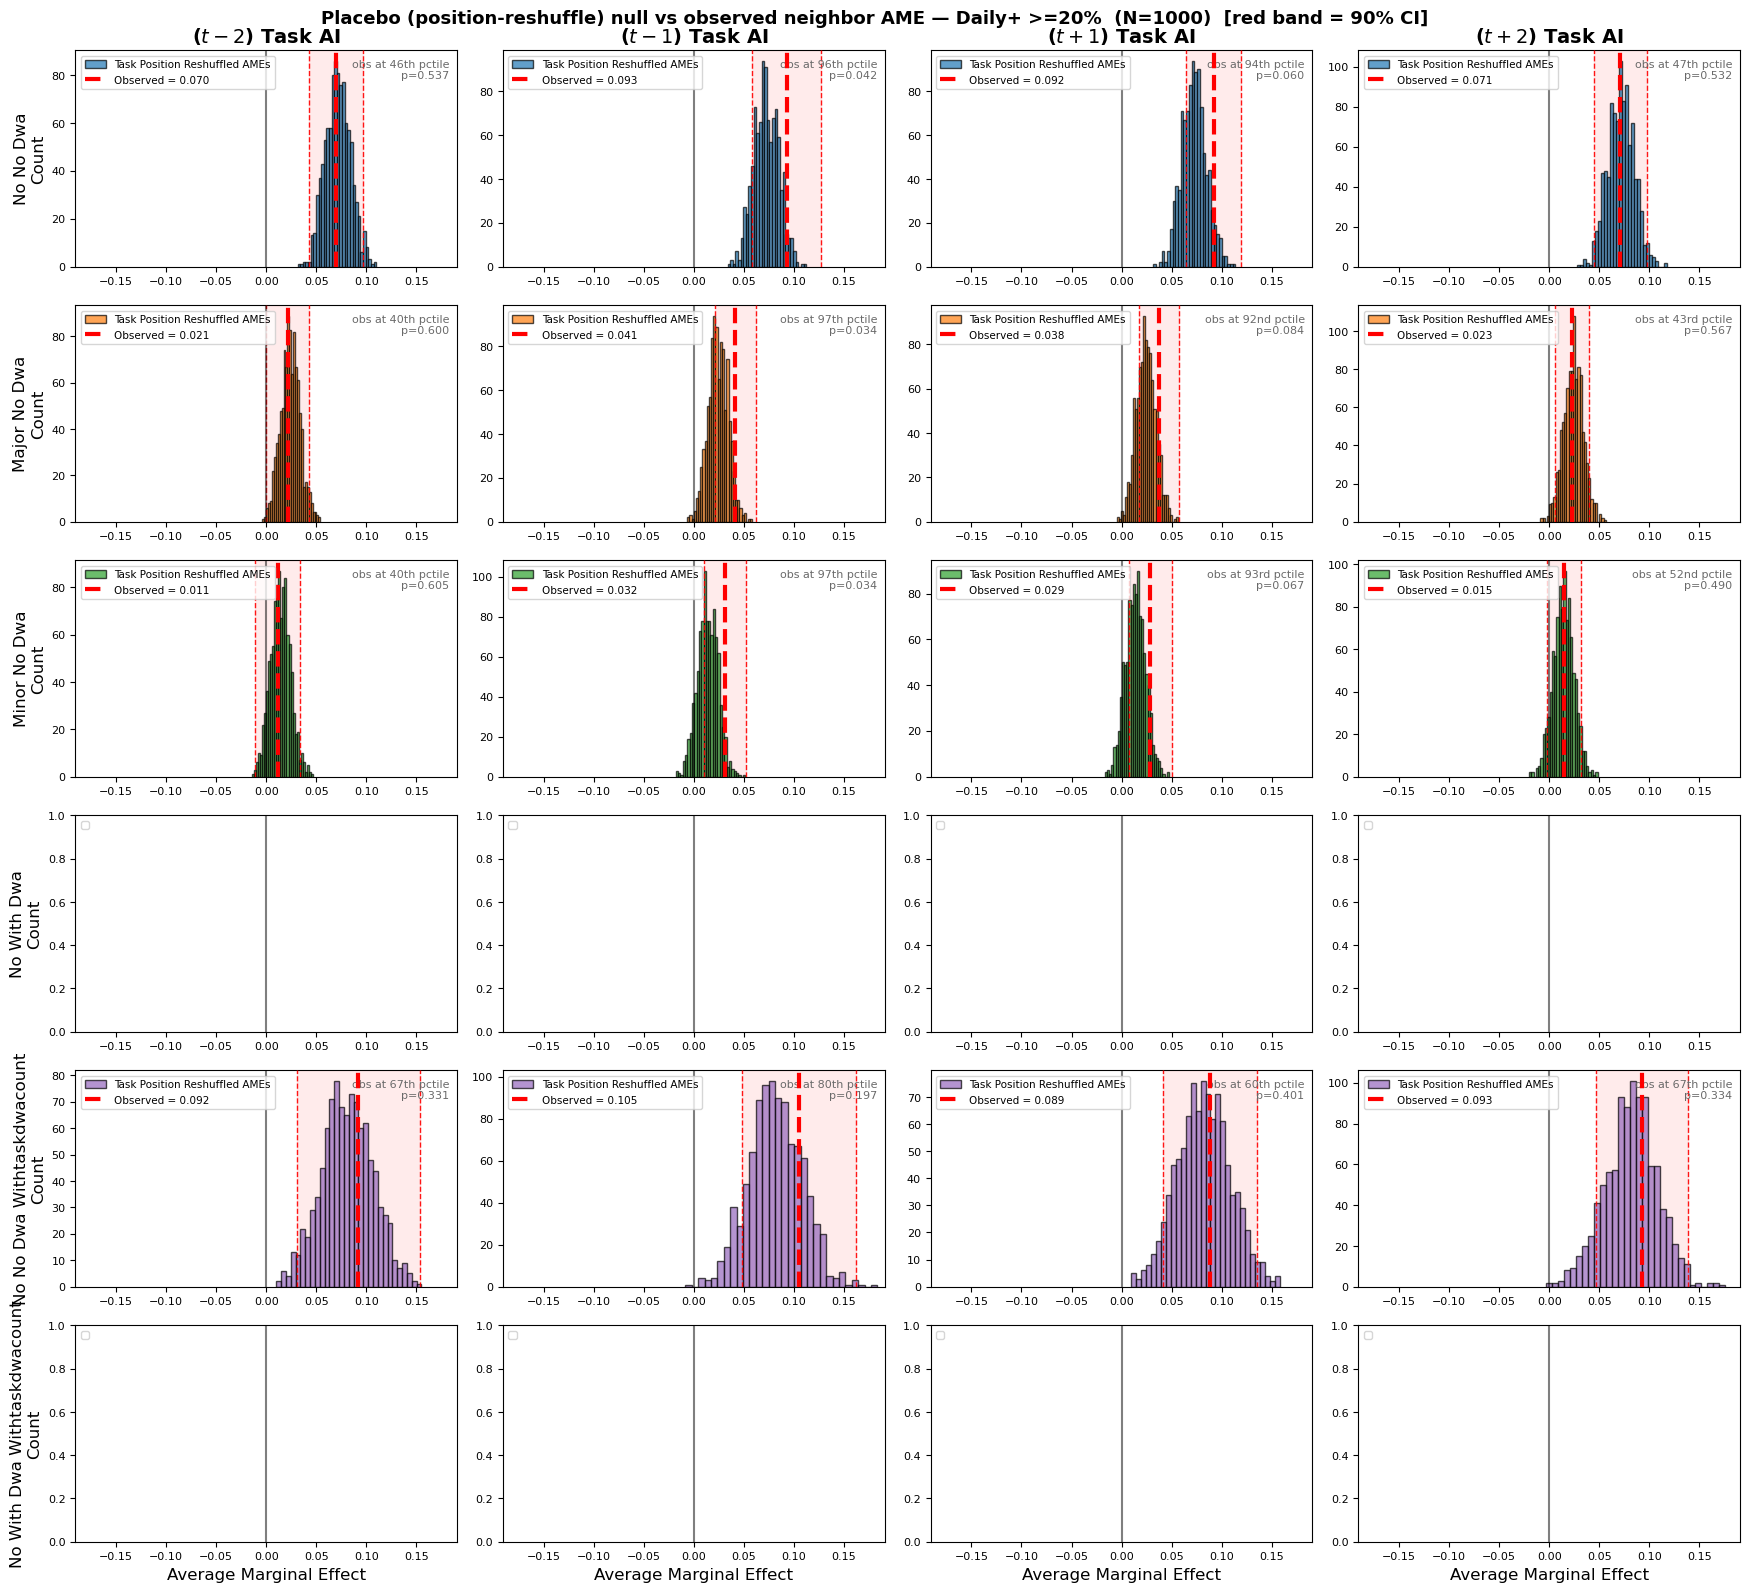

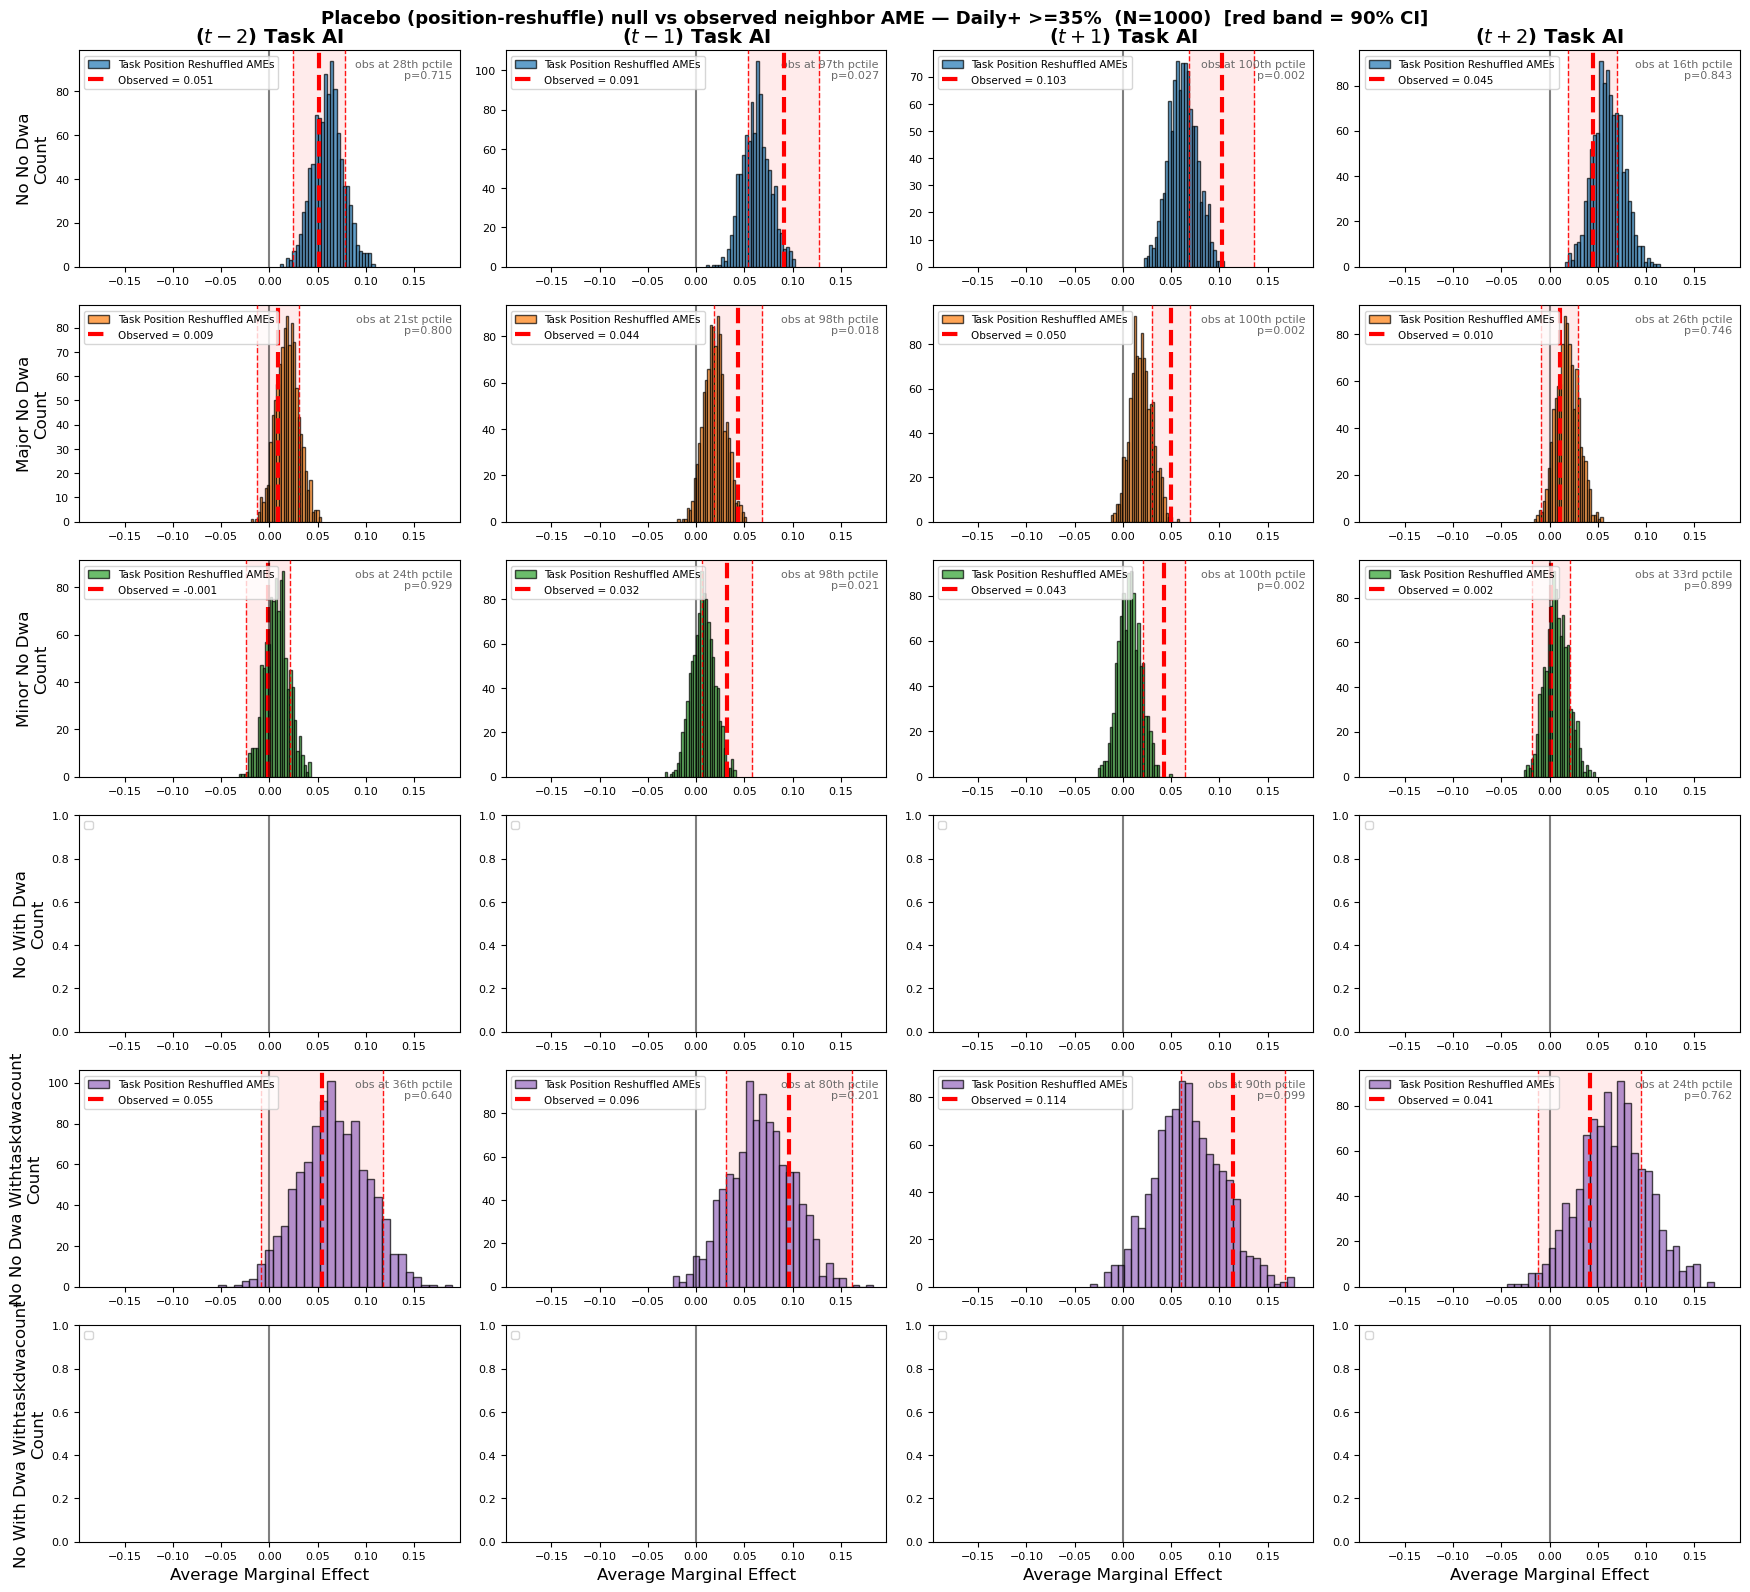

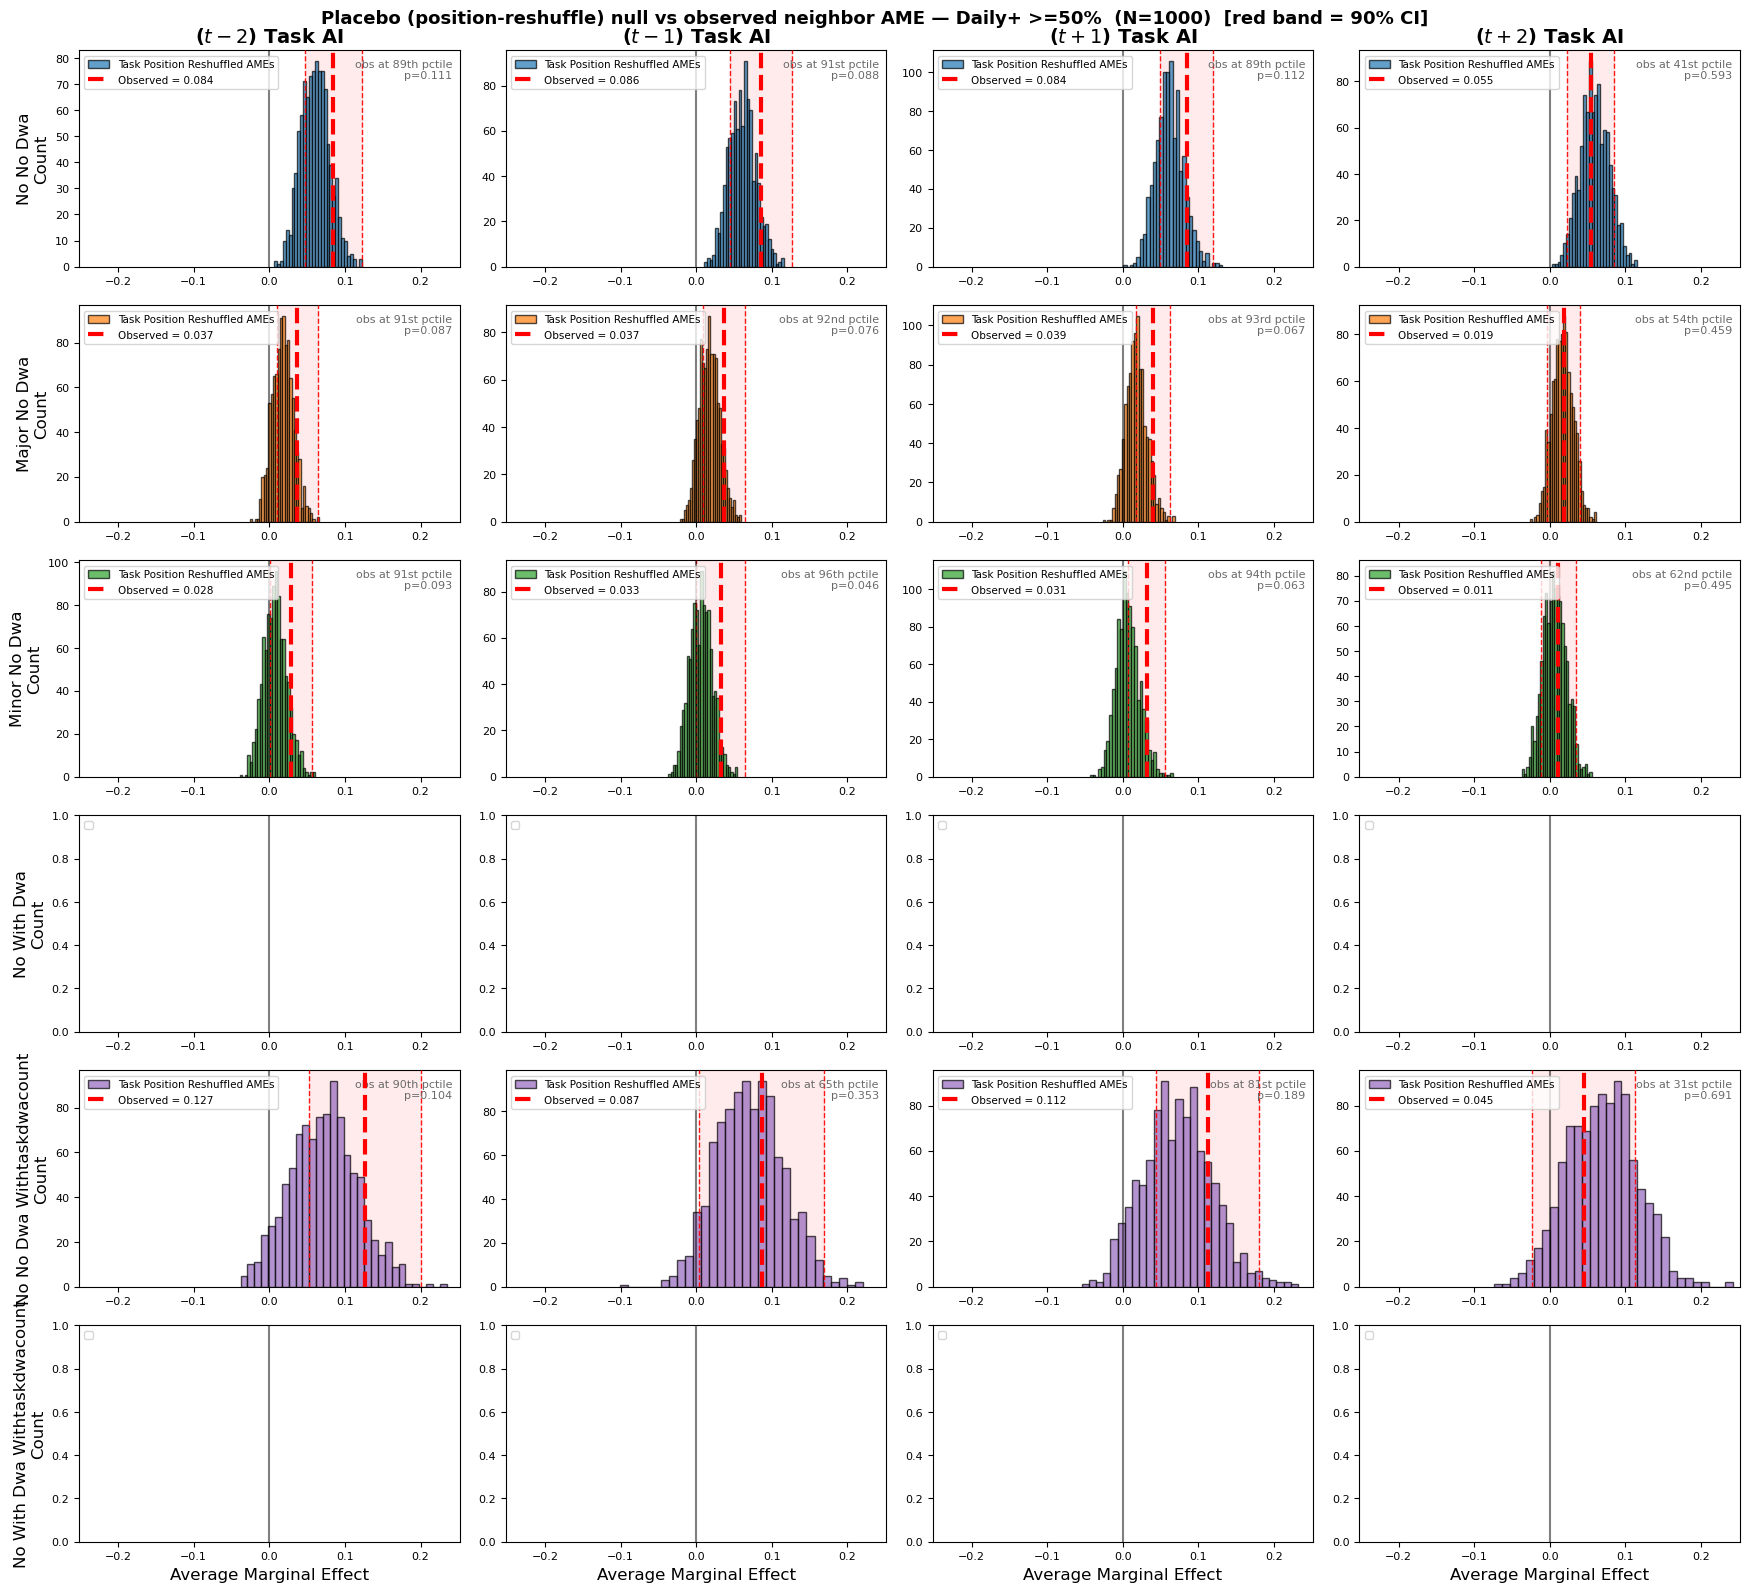

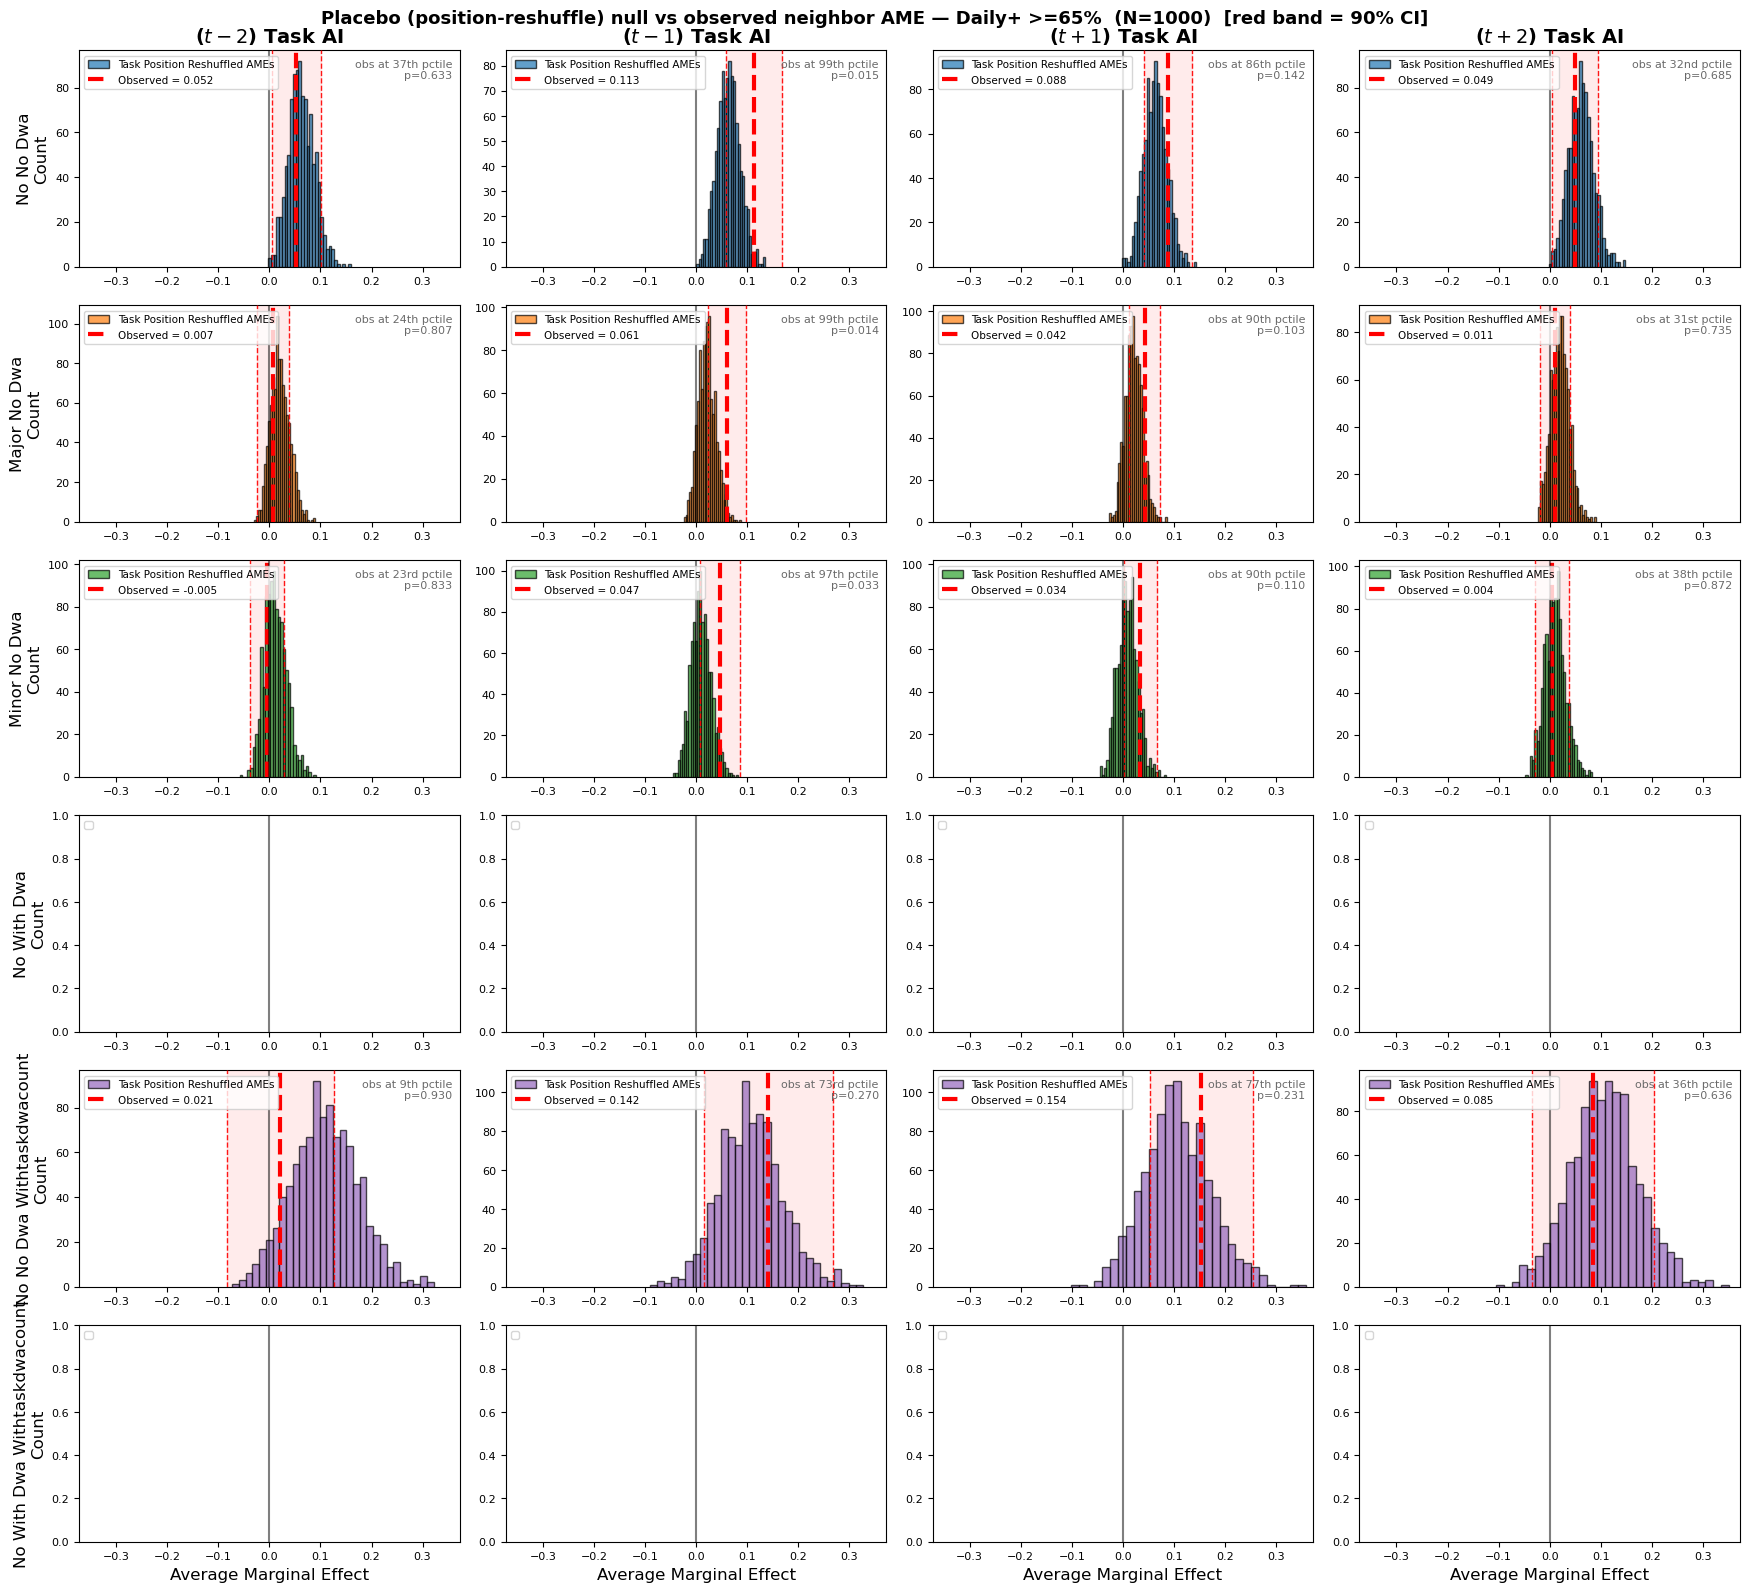

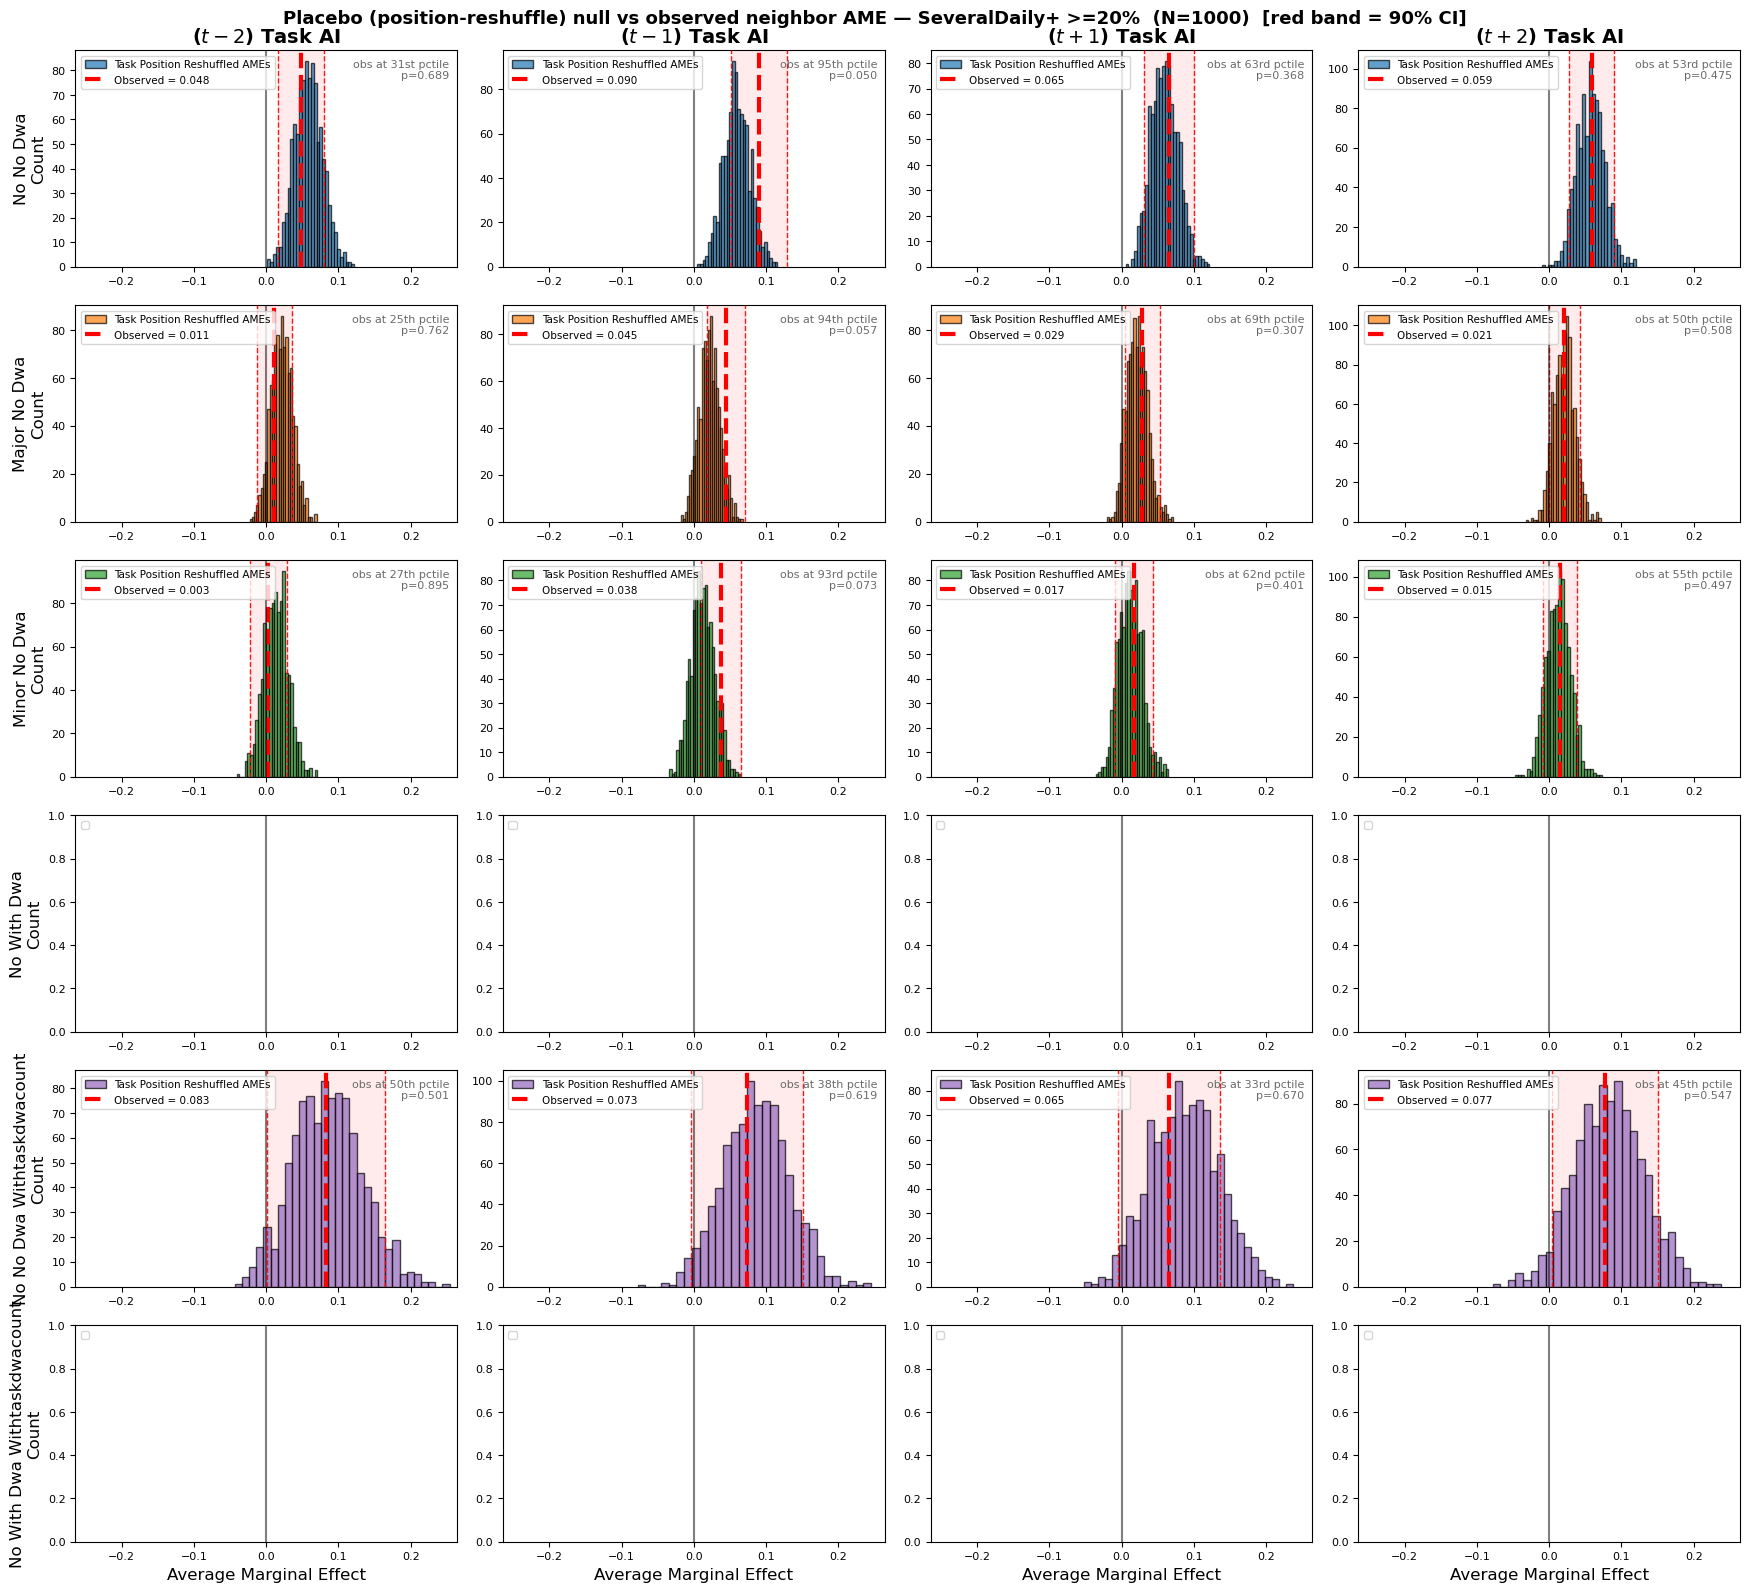

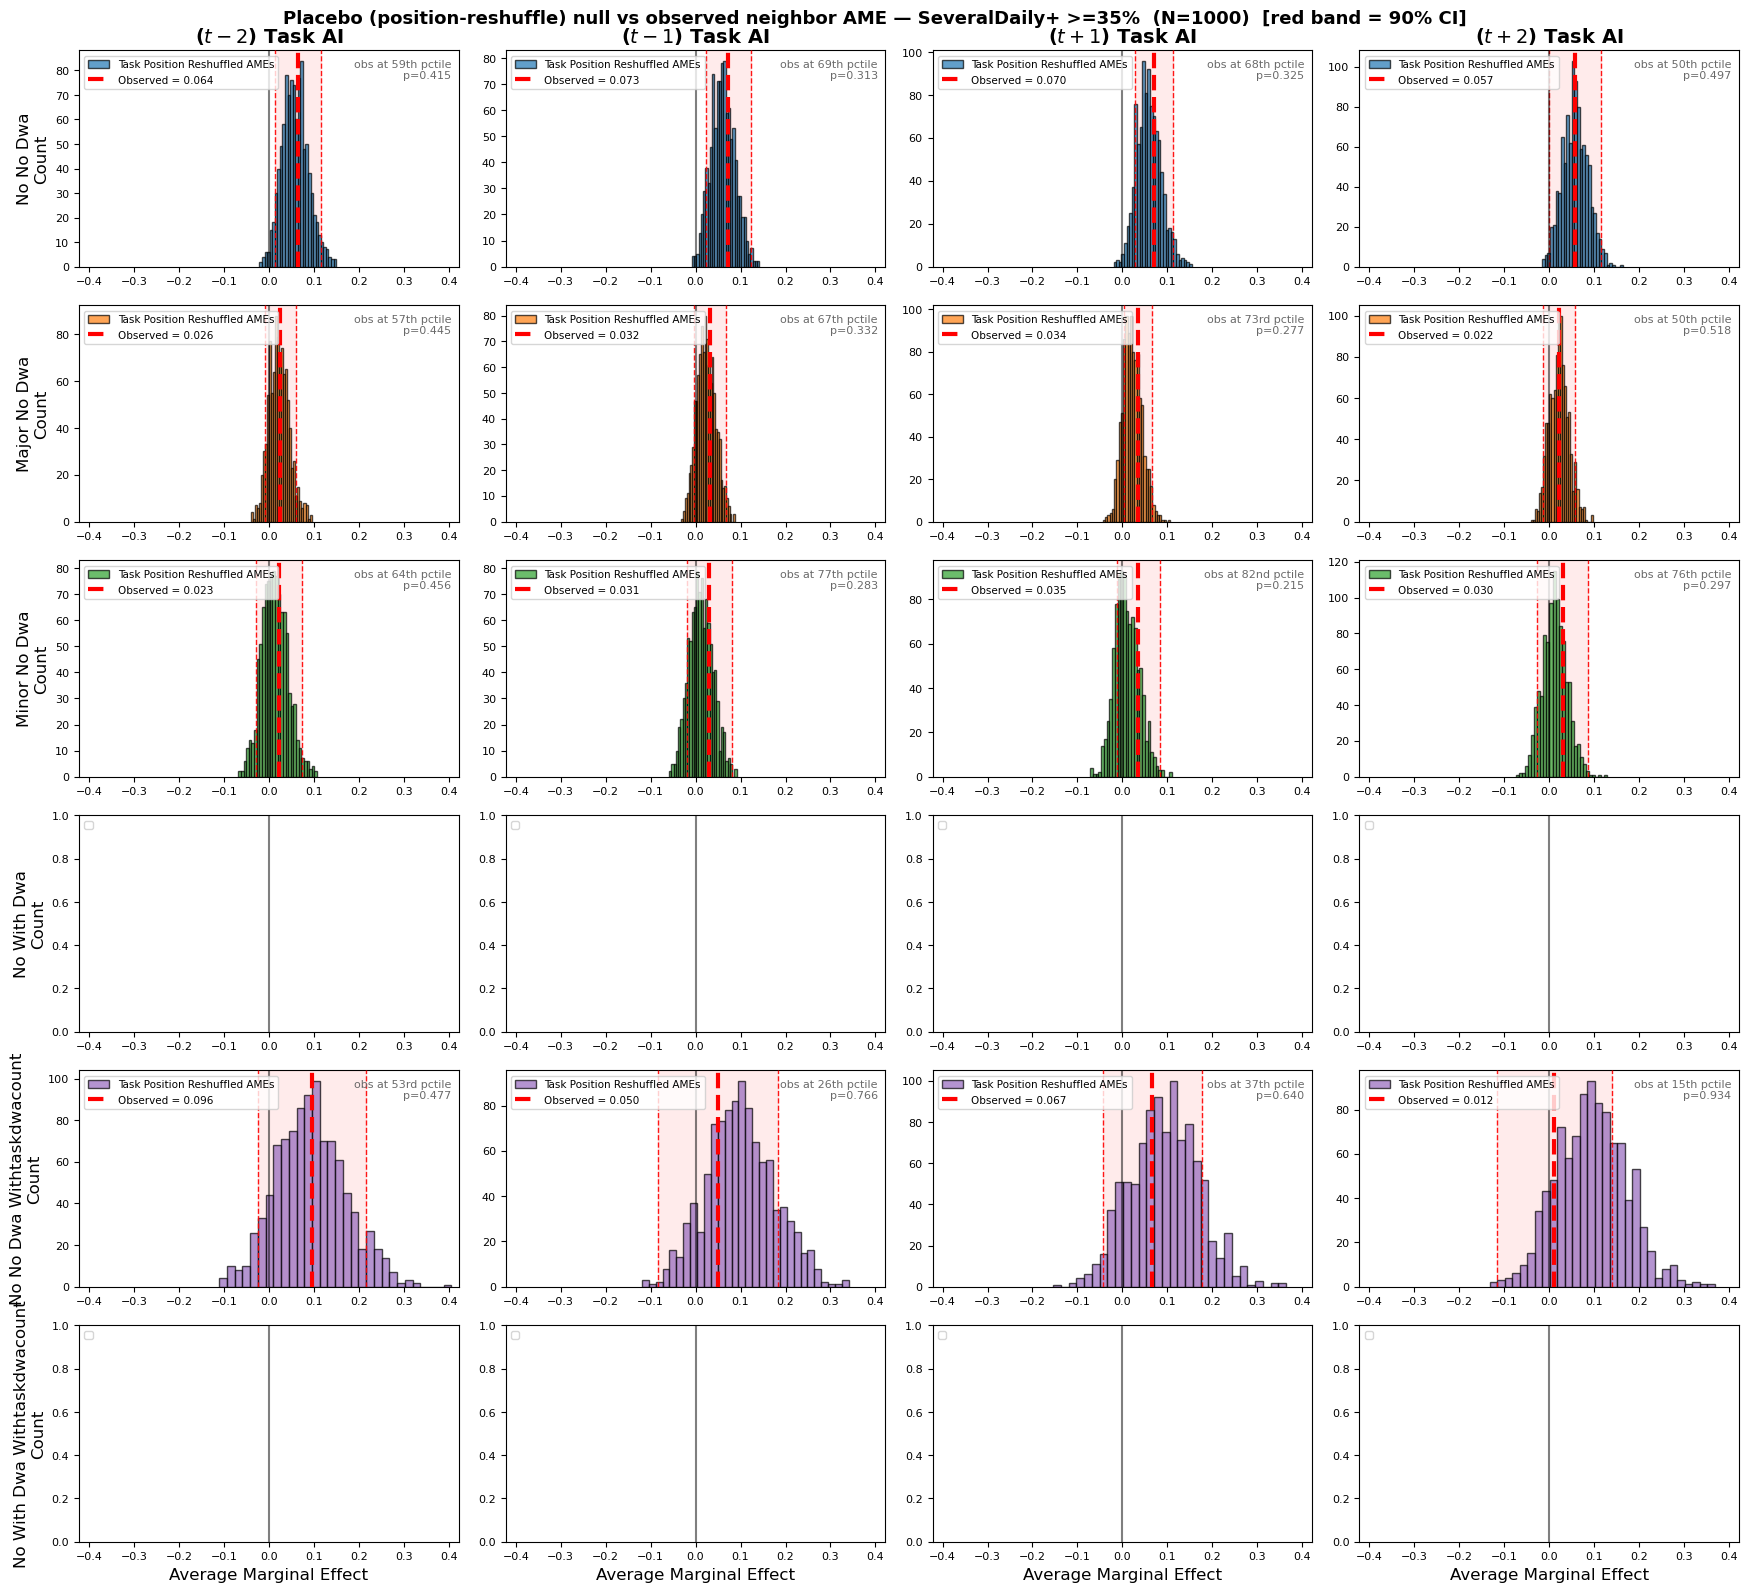

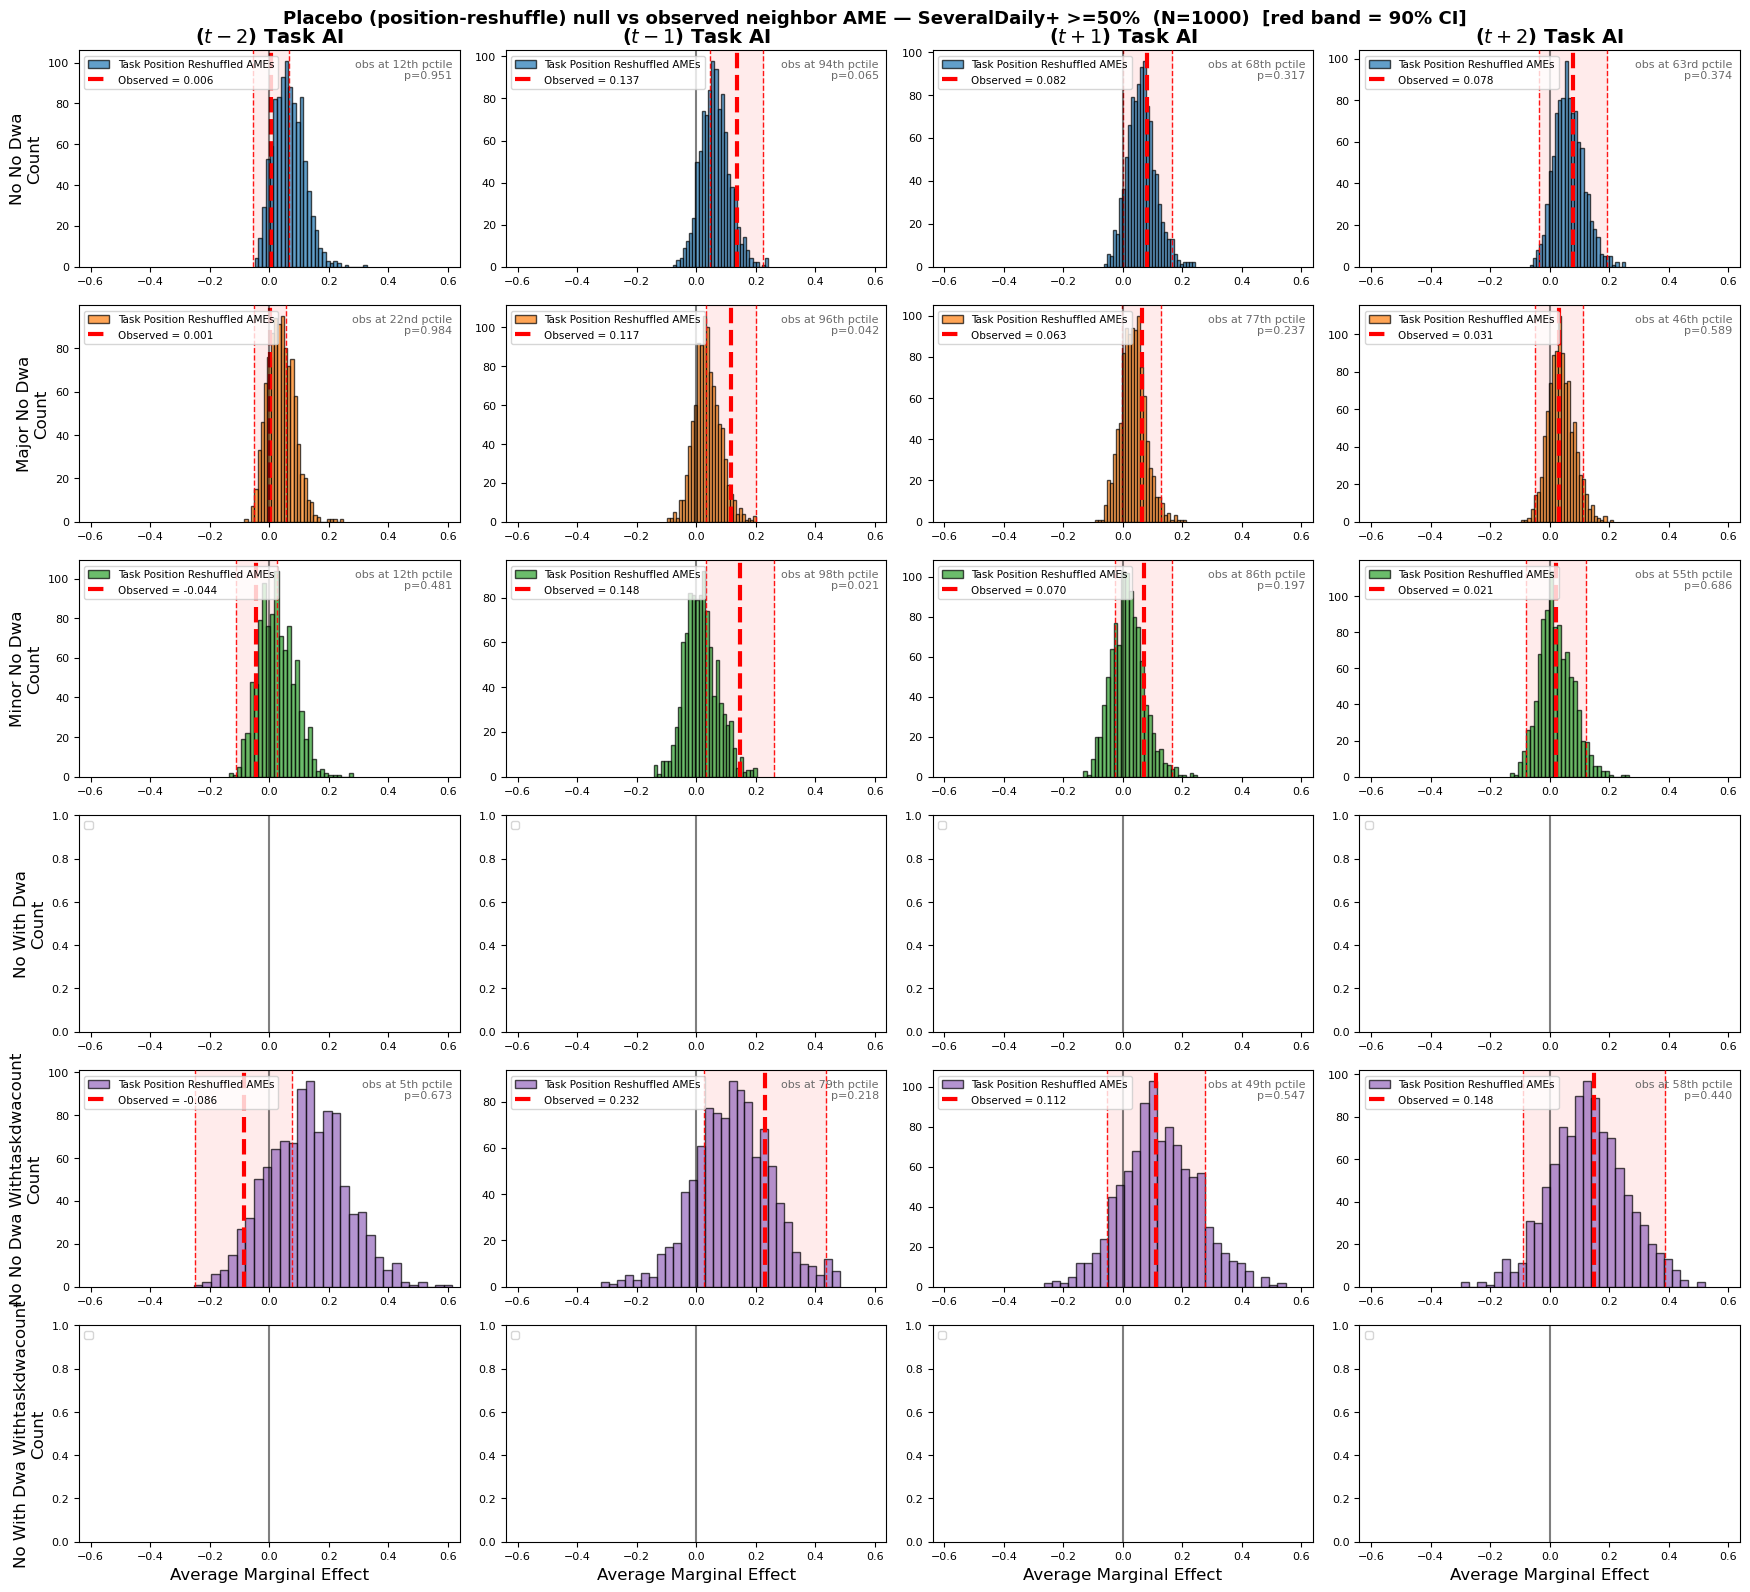

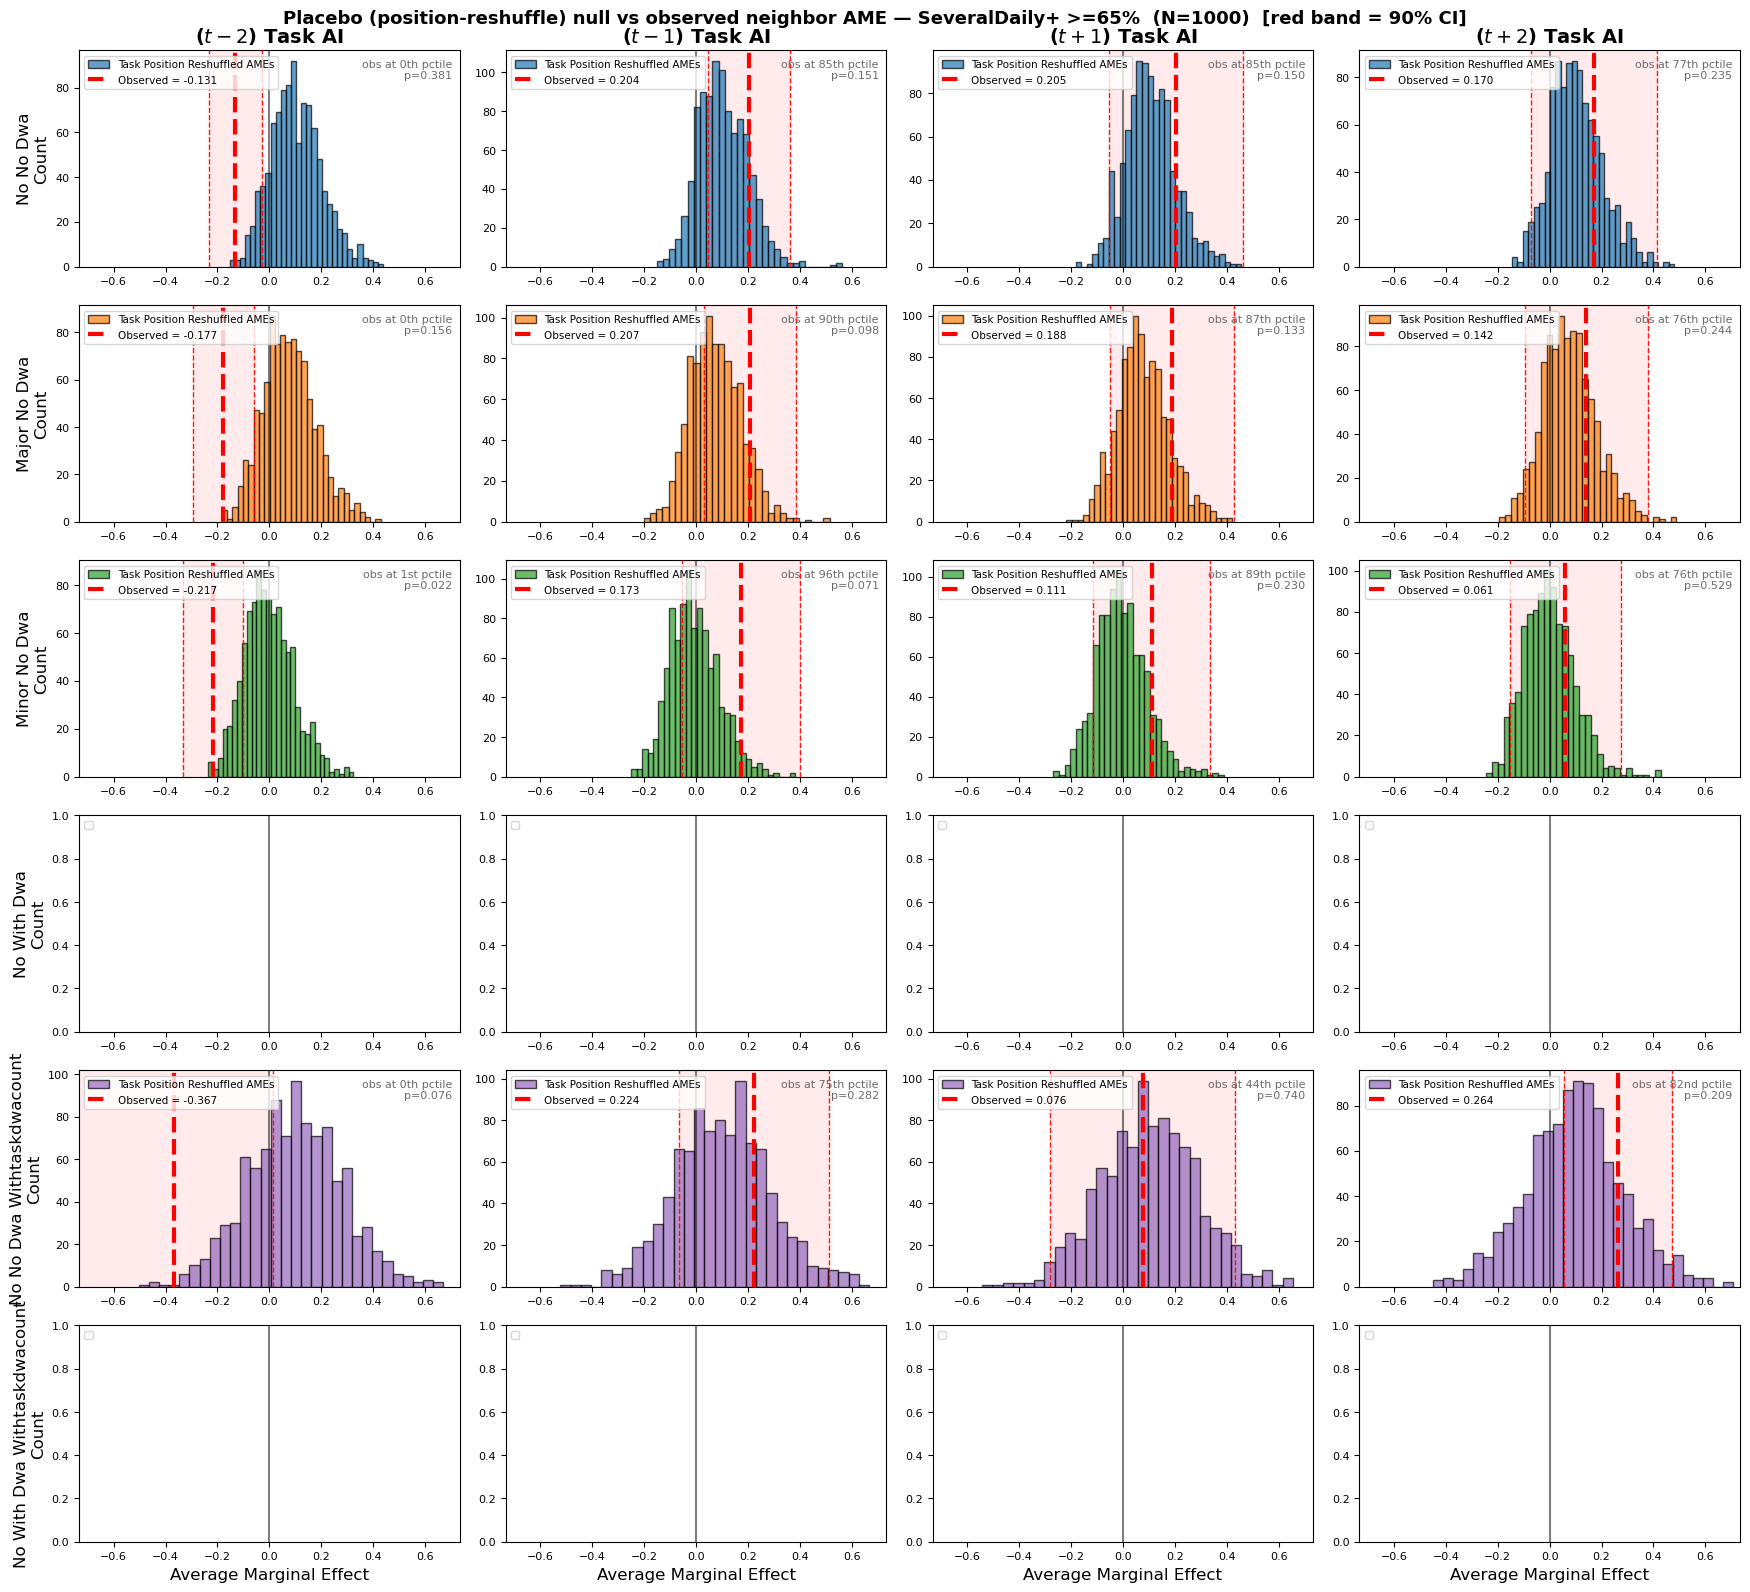

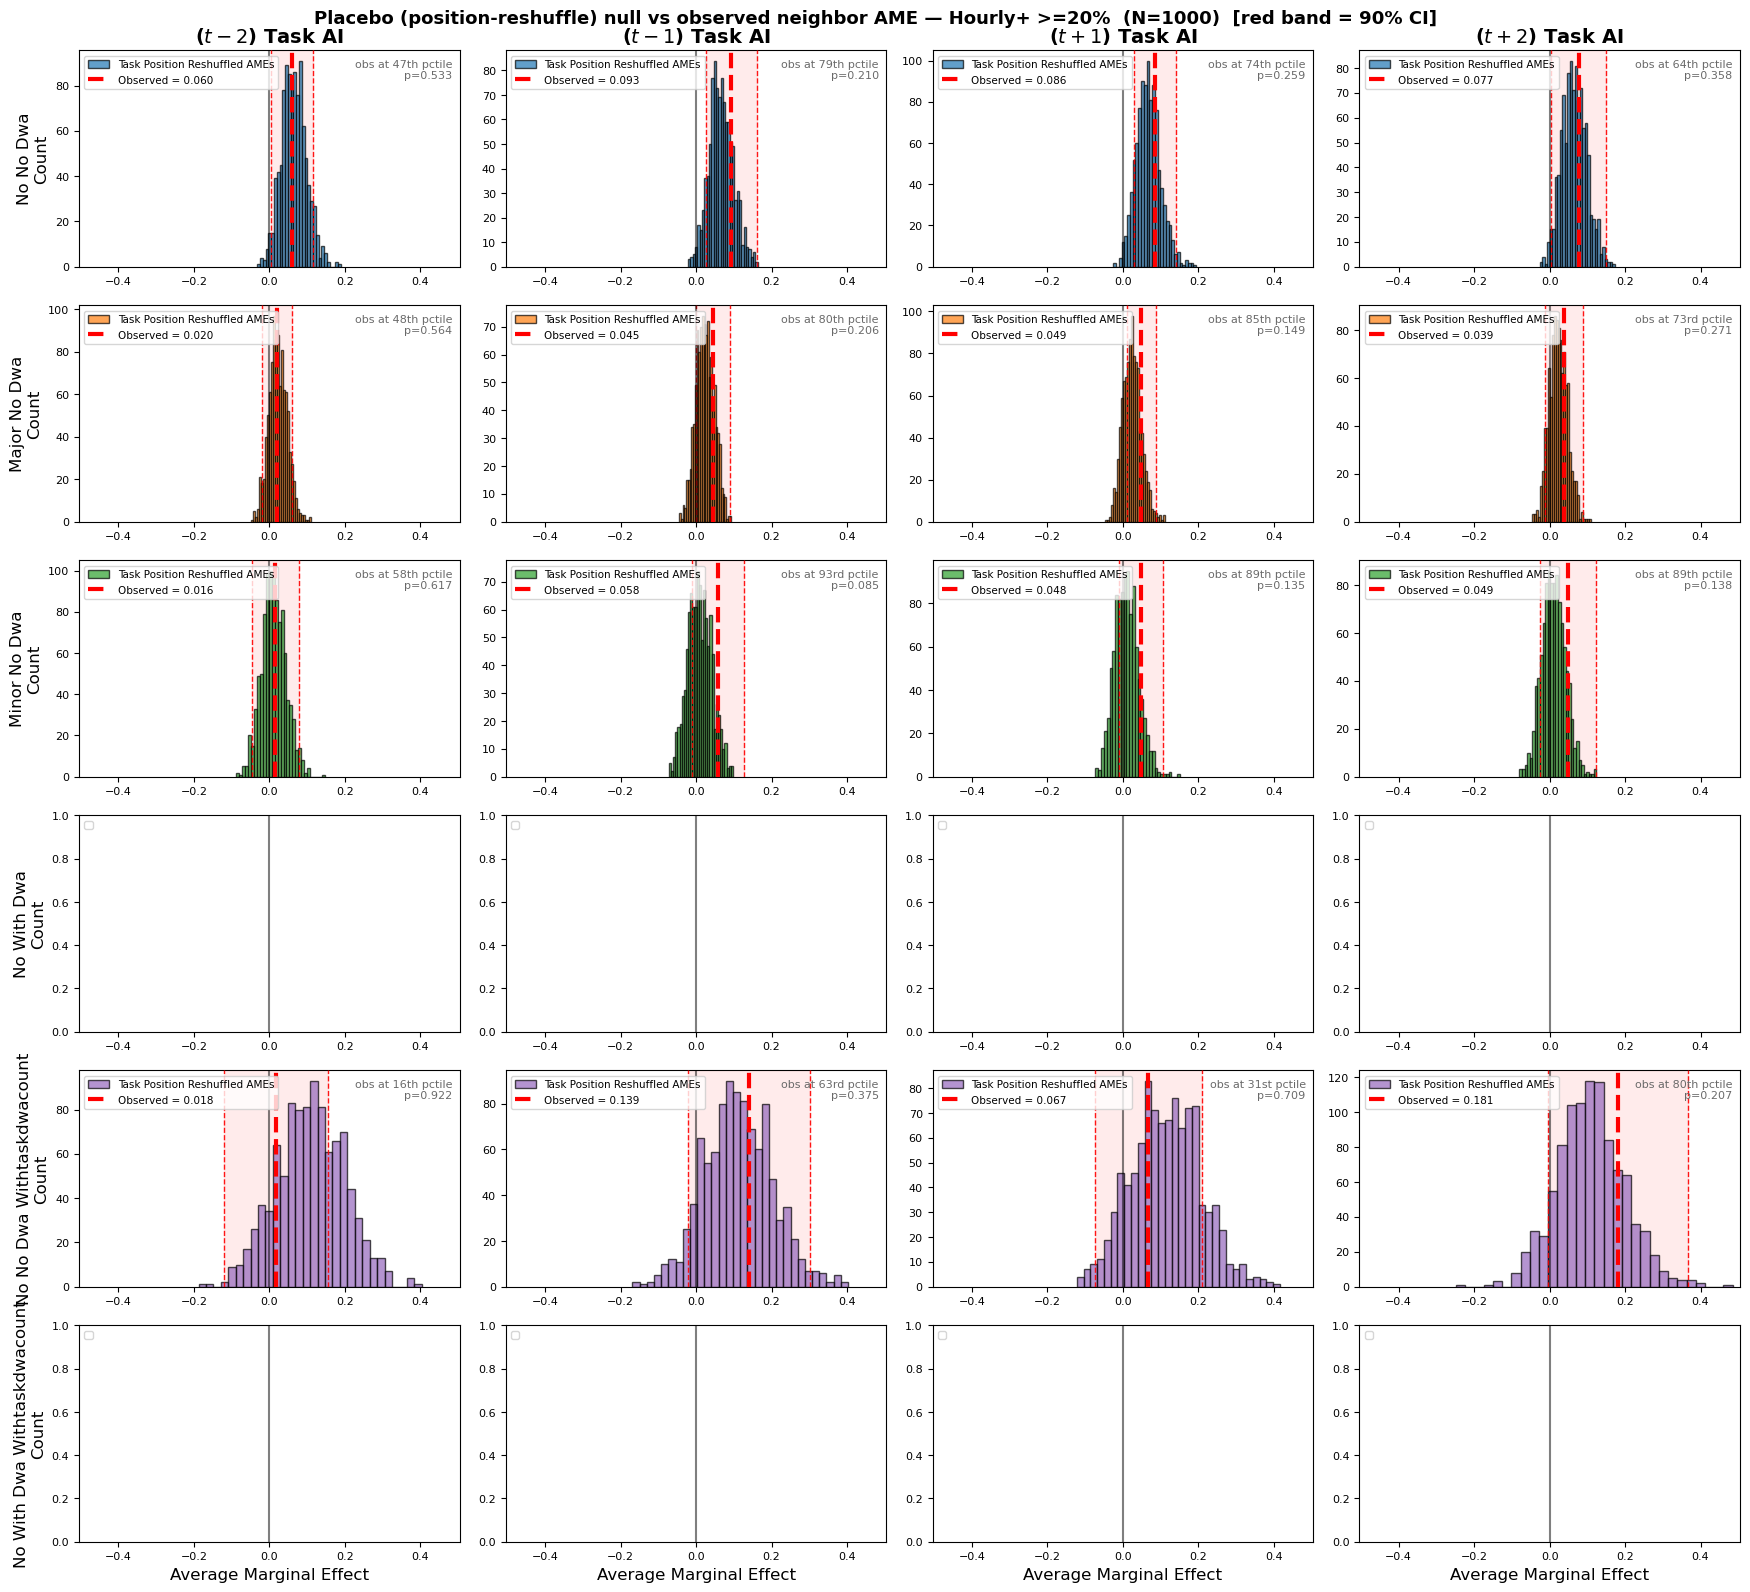

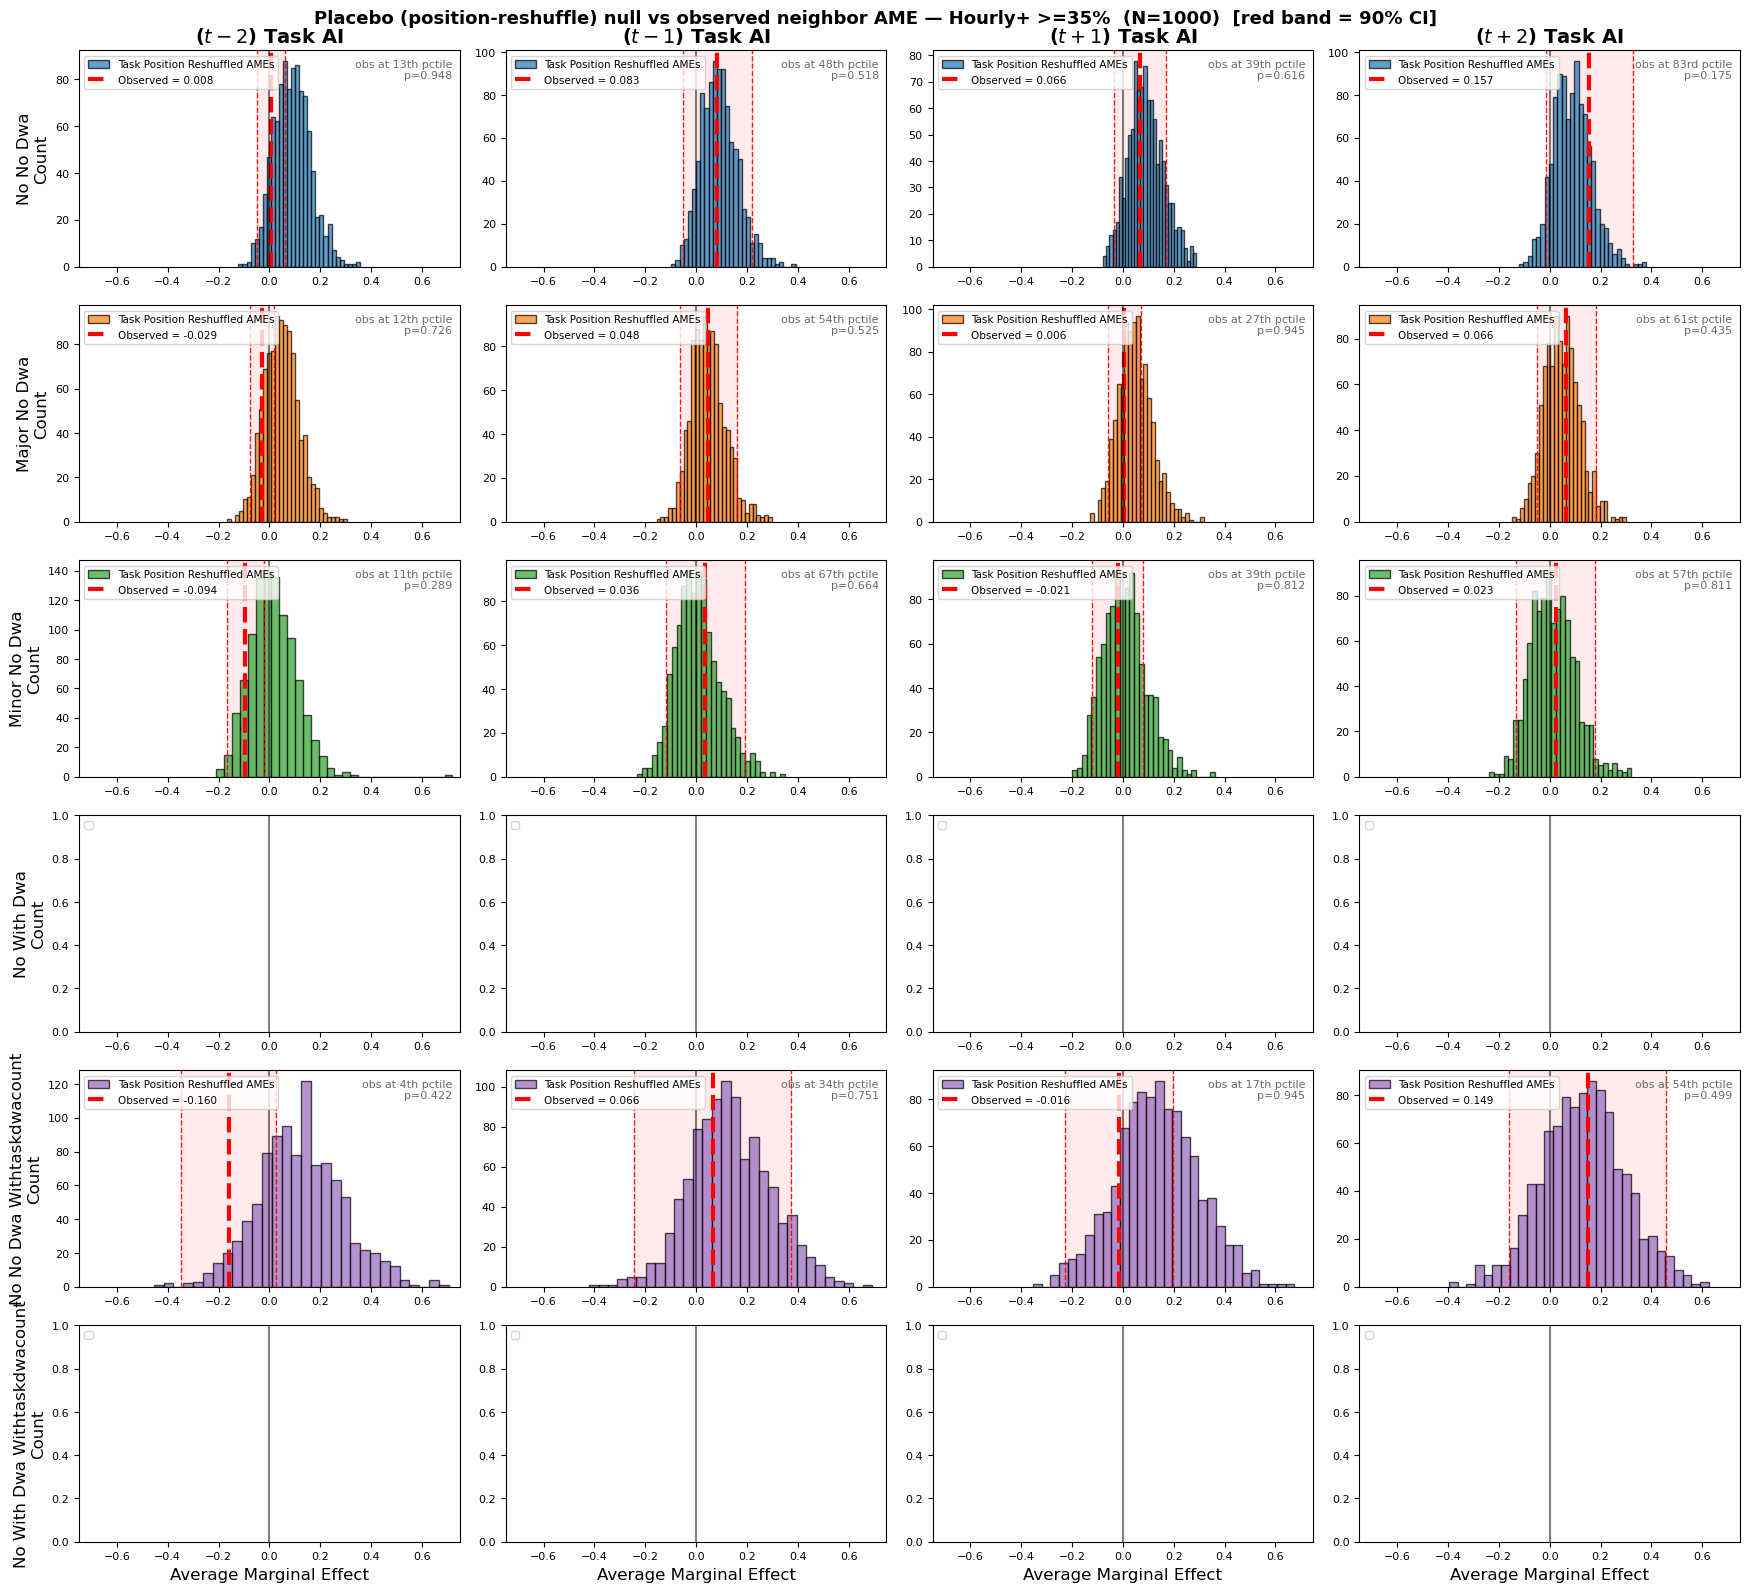

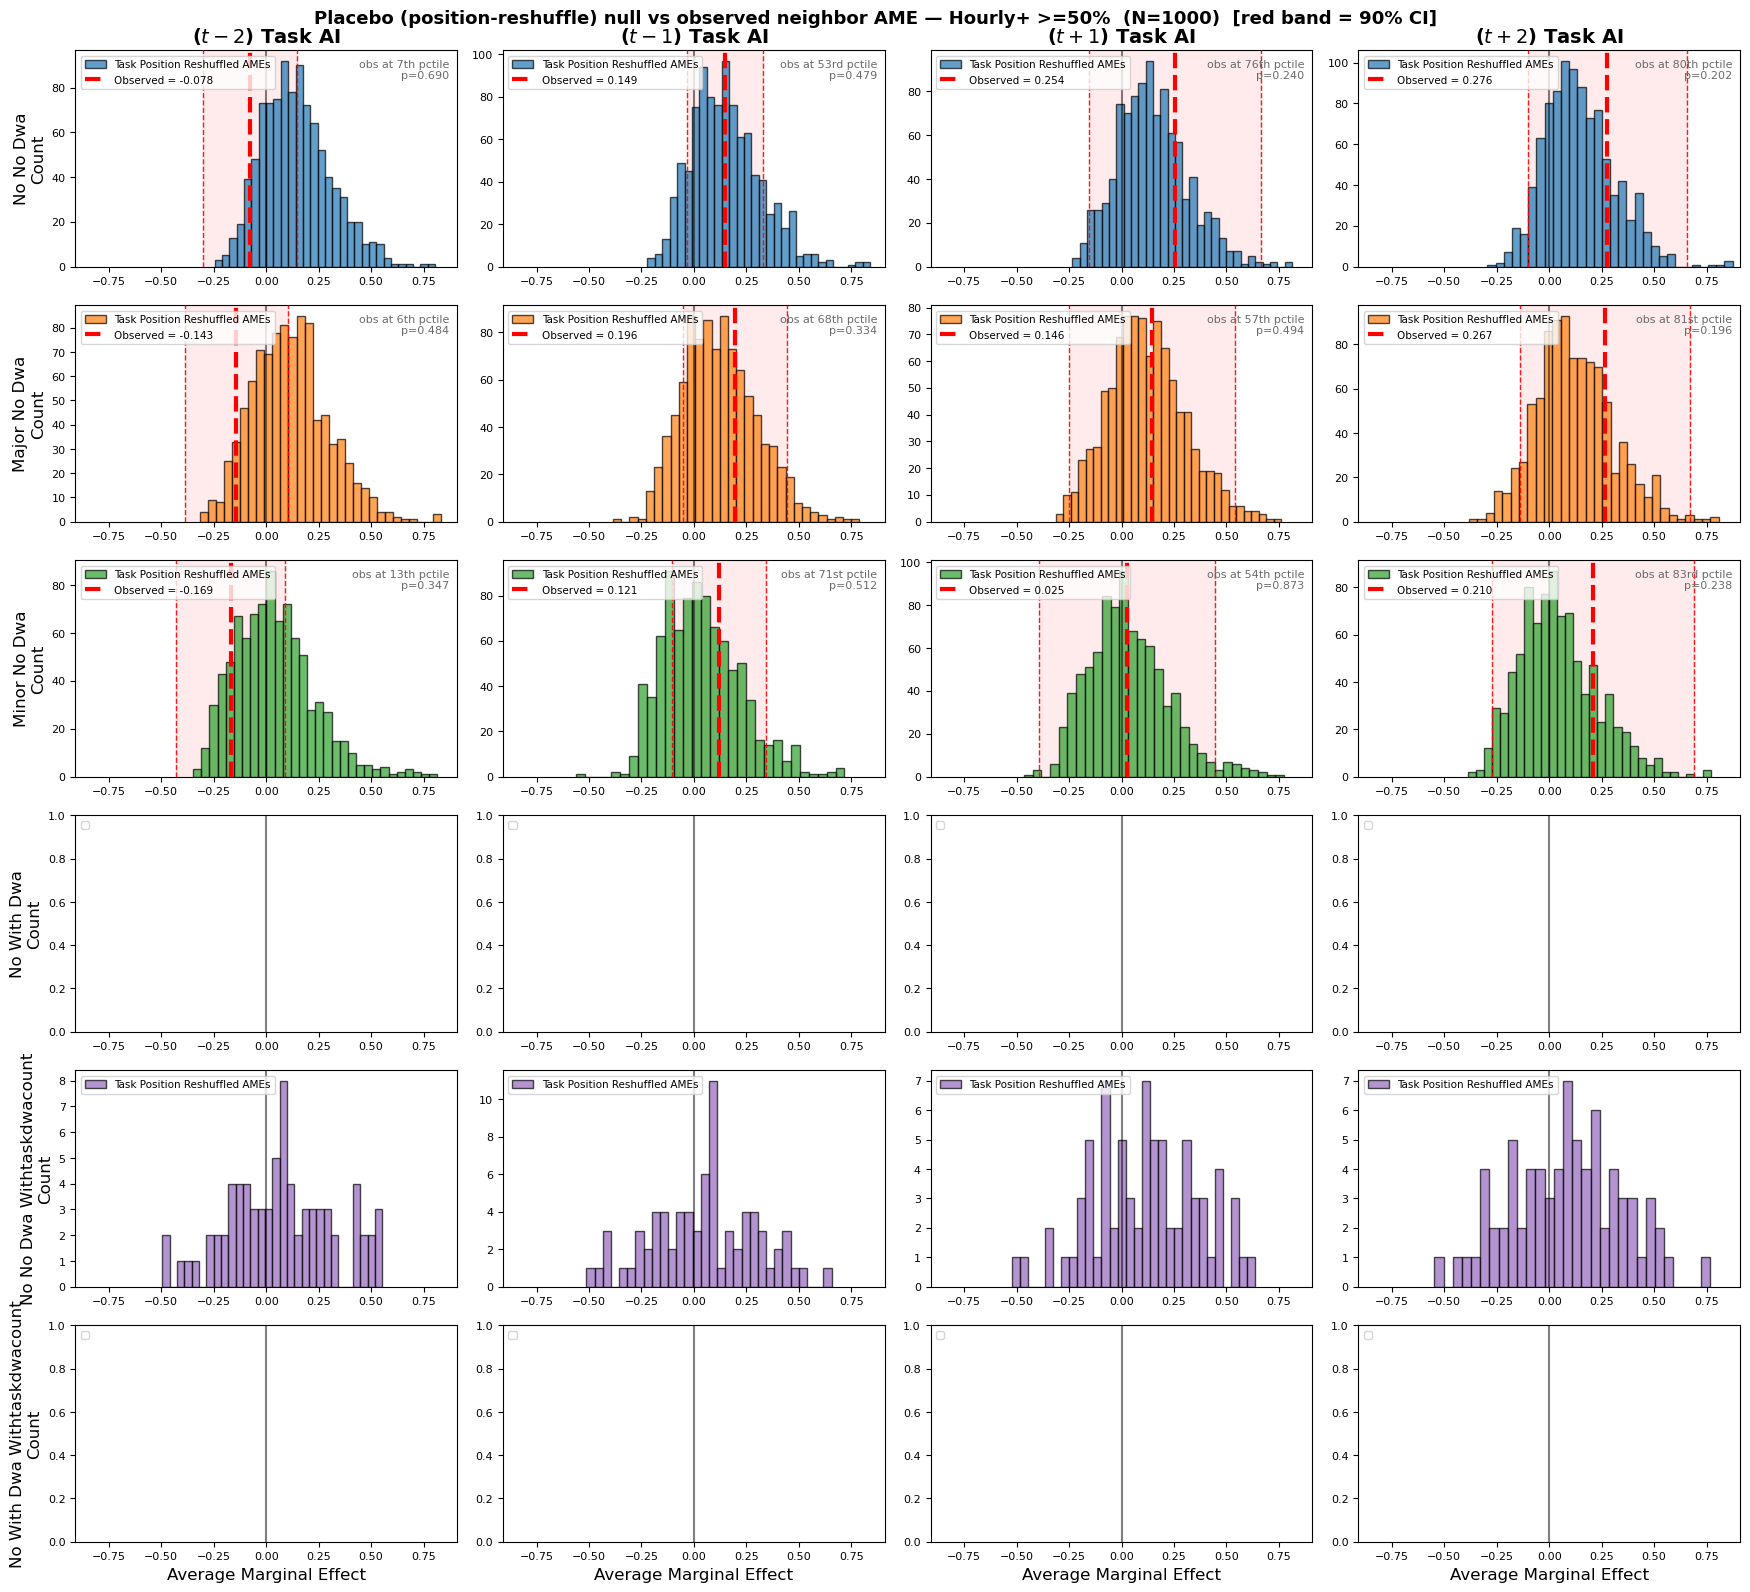

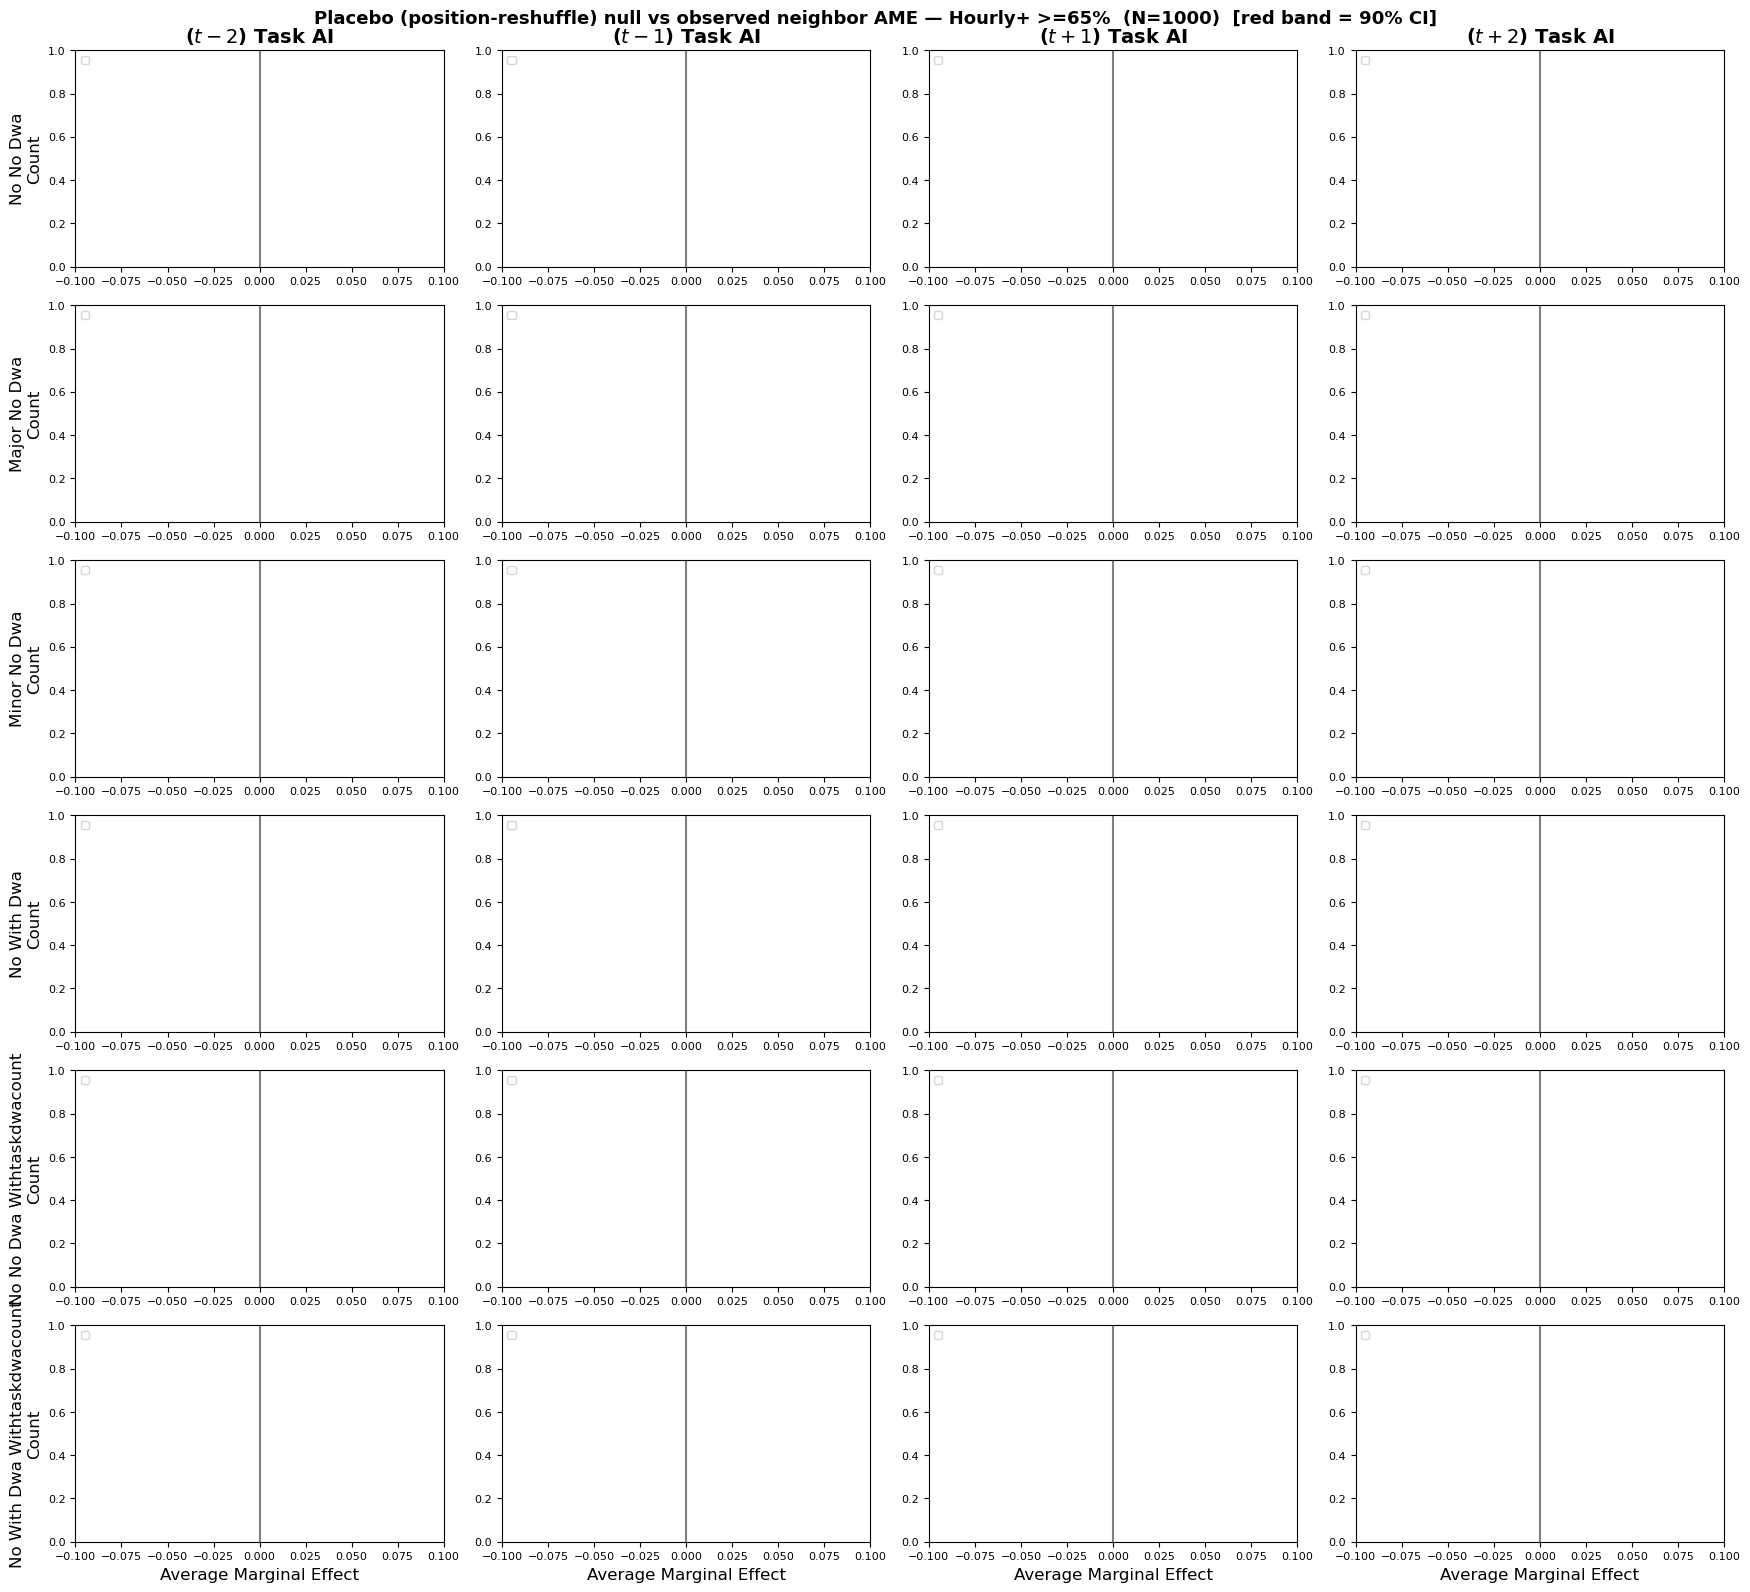

Saved 13 placebo figures (tab10 palette + 90% CI band) to ../writeup/plots/execTypeVaryingDWA_weeklyTasks/placebo


In [9]:
# Styling matched to the main-results placebo figure (AME_full_is_ai.png):
# tab10 colour per spec row, red dashed observed line, red-shaded 90% CI band (obs +/- 1.645*SE).
VAR_LABELS = {'prev2_is_ai':'($t-2$) Task AI', 'prev_is_ai':'($t-1$) Task AI',
              'next_is_ai':'($t+1$) Task AI', 'next2_is_ai':'($t+2$) Task AI'}
SPEC_COLORS = [plt.cm.tab10(i % 10) for i in range(len(SPEC_ORDER))]
N_DRAWS = int(null_df['draw'].nunique())

def rand_p(null_vals, obs):
    v = np.asarray([x for x in null_vals if not np.isnan(x)], dtype=float)
    if not len(v) or np.isnan(obs): return np.nan
    return (1 + np.sum(np.abs(v) >= abs(obs))) / (1 + len(v))

def pctile(null_vals, obs):
    '''Percentile of the placebo (null) distribution that the observed value falls into.'''
    v = np.asarray([x for x in null_vals if not np.isnan(x)], dtype=float)
    if not len(v) or np.isnan(obs): return np.nan
    return 100.0 * np.mean(v < obs)

def _ord(n):
    n = int(round(n)); suf = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10 if n % 100 not in (11, 12, 13) else 0, 'th'); return f"{n}{suf}"

def plot_cut(tag, label):
    sub = null_df[null_df.cut_tag == tag]
    allv = [x for x in sub['ame'].tolist() if not np.isnan(x)] + \
           [observed[tag][s][t][0] for s in SPEC_ORDER for t in TARGET_REGS if not np.isnan(observed[tag][s][t][0])]
    bnd = max(abs(min(allv)), abs(max(allv))) * 1.04 if allv else 0.1
    fig, axes = plt.subplots(len(SPEC_ORDER), len(TARGET_REGS),
                             figsize=(4.4*len(TARGET_REGS), 2.7*len(SPEC_ORDER)), squeeze=False)
    for r, spec in enumerate(SPEC_ORDER):
        cr = SPEC_COLORS[r]; clean_spec = spec.replace('fe_', '').replace('_', ' ').title()
        for c, term in enumerate(TARGET_REGS):
            ax = axes[r][c]
            vals = sub[(sub.spec==spec) & (sub.term==term)]['ame']; vals = vals[~vals.isna()]
            obs, se = observed[tag][spec][term]
            if len(vals):
                ax.hist(vals, bins=30, color=cr, alpha=0.7, edgecolor='k',
                        label='Task Position Reshuffled AMEs', zorder=2)
            if not np.isnan(obs) and not np.isnan(se):
                band = 1.645 * se
                ax.axvspan(obs-band, obs+band, color='red', alpha=0.08, zorder=1)
                ax.axvline(obs-band, color='red', ls='--', lw=1, alpha=0.9, zorder=3)
                ax.axvline(obs+band, color='red', ls='--', lw=1, alpha=0.9, zorder=3)
            if not np.isnan(obs):
                ax.axvline(obs, color='red', ls='--', lw=3, label=f'Observed = {obs:.3f}', zorder=4)
            ax.axvline(0.0, color='black', ls='-', lw=1.5, alpha=0.5, zorder=4)
            ax.set_xlim(-bnd, bnd); ax.tick_params(labelsize=8)
            ax.legend(fontsize=7.5, loc='upper left')
            p = rand_p(vals.tolist(), obs); pc = pctile(vals.tolist(), obs)
            ann = ([f"obs at {_ord(pc)} pctile"] if not np.isnan(pc) else []) + ([f"p={p:.3f}"] if not np.isnan(p) else [])
            if ann:
                ax.text(0.98, 0.96, "\n".join(ann), transform=ax.transAxes, ha='right', va='top', fontsize=8, color='dimgray')
            if r == 0: ax.set_title(VAR_LABELS[term], fontsize=14, fontweight='bold')
            if r == len(SPEC_ORDER)-1: ax.set_xlabel('Average Marginal Effect', fontsize=12)
            if c == 0: ax.set_ylabel(f'{clean_spec}\nCount', fontsize=12)
    fig.suptitle(f"Placebo (position-reshuffle) null vs observed neighbor AME — {label}  (N={N_DRAWS})  [red band = 90% CI]",
                 fontweight='bold', fontsize=13)
    fig.tight_layout()
    fig.savefig(f"{output_plot_path}/placebo_{tag}.png", dpi=130, bbox_inches='tight')
    plt.show(); plt.close(fig)

for label, tag, cols, thr in PLACEBO_CUTS:
    plot_cut(tag, label)
print(f"Saved {len(PLACEBO_CUTS)} placebo figures (tab10 palette + 90% CI band) to {output_plot_path}")

## Notes

- **Full run** at `N_RESHUFFLES = 1000` (~1.1 h; timing trial measured ~4.0 s/draw). Null draws are saved
  incrementally to `placebo_null_draws.csv` every 10% so the run is recoverable.
- The shuffle reuses the paper's mechanic and seeds (`random_state = 42 + i`); one shuffle per draw is shared
  across all cuts (filter applied to the shuffled sequence), per the requested design.
- Null draws saved to `placebo_null_draws.csv`, observed AMEs to `placebo_observed.csv`, figures under
  `writeup/plots/execTypeVaryingDWA_weeklyTasks/placebo/`.